# Analisis de spotify

## Librerias

In [ ]:
"""
Sección de Importación de Librerías y Módulos.

Las librerías se organizan según su función dentro del proyecto:
- Utilidades generales y comunicación con recursos externos.
- Manipulación y procesamiento de datos.
- Visualización para el análisis exploratorio.
- Preprocesamiento y preparación de datos para Machine Learning.

Esta organización facilita la lectura, mantenimiento y reutilización del código
durante las distintas etapas del proyecto, desde la carga y exploración de los
datos hasta su preparación para el entrenamiento de los modelos.
"""

# 1. Utilidades generales y comunicación con recursos externos
import math       # Proporciona funciones matemáticas y operaciones numéricas básicas.
import hashlib    # Permite generar funciones hash para identificar o verificar datos.
import io         # Proporciona herramientas para trabajar con datos en memoria como archivos.
import requests   # Permite realizar solicitudes HTTP y acceder a recursos externos.

# 2. Manipulación y procesamiento de datos
import numpy as np   # Permite realizar operaciones numéricas eficientes sobre arrays y matrices.
import pandas as pd  # Permite trabajar con datos tabulares mediante Series y DataFrames.

# 3. Visualización de datos y Análisis Exploratorio (EDA)
import matplotlib.pyplot as plt  # Permite crear gráficos y visualizaciones de datos.
import seaborn as sns             # Extiende Matplotlib con visualizaciones estadísticas de alto nivel.

# 4. Machine Learning y Preprocesamiento (Scikit-Learn)
from sklearn.model_selection import train_test_split
# Permite dividir los datos en conjuntos de entrenamiento y prueba.

from sklearn.base import BaseEstimator, TransformerMixin
# Permite crear transformadores personalizados compatibles con Scikit-Learn.

from sklearn.compose import ColumnTransformer
# Permite aplicar diferentes transformaciones a distintos grupos de columnas.

from sklearn.pipeline import Pipeline
# Permite encadenar transformaciones y etapas de procesamiento en un flujo reproducible.

from sklearn.preprocessing import OneHotEncoder, StandardScaler
# OneHotEncoder transforma variables categóricas en variables binarias.
# StandardScaler estandariza las variables numéricas utilizando media y desviación estándar.

# 5. Utilidades para manejo de archivos y directorios
import os
# Permite interactuar con el sistema operativo, gestionar rutas y crear directorios.

## Cargar set de datos

In [ ]:
# obtener hash
url = "https://raw.githubusercontent.com/YorkiOprogramador/Evaluacion1_MachineLearning/main/data/Spotify_Tracks_Dataset.csv"
respuesta = requests.get(url)
hash_calculado = hashlib.sha256(respuesta.content).hexdigest()
print("Hash calculado:", hash_calculado)

Hash calculado: b202fa49909b2d5cef71a04b1d21243cfeb36414535f2ca9272aa646721177bd


In [ ]:
"""
Script para la descarga y validación criptográfica de un set de datos.

Este bloque de código obtiene un archivo CSV directamente desde un
repositorio de GitHub en su formato Raw. Antes de cargarlo en un
DataFrame de Pandas, utiliza la librería hashlib para generar un
hash SHA-256 del contenido descargado y lo compara con un hash de
referencia (previamente auditado).

El objetivo es garantizar la integridad completa del archivo,
asegurando que los datos no hayan sido alterados, corrompidos ni
manipulados externamente, previniendo así la ejecución de modelos
sesgados o vulnerados.
"""

# 1. Configuración de la URL
url = "https://raw.githubusercontent.com/YorkiOprogramador/Evaluacion1_MachineLearning/main/data/Spotify_Tracks_Dataset.csv"

# 2. Define tu Hash esperado (Copia aquí el hash calculado la primera vez que lo ejecutes)
hash_esperado = "b202fa49909b2d5cef71a04b1d21243cfeb36414535f2ca9272aa646721177bd"

# 3. Obtener el contenido del archivo desde la web
respuesta = requests.get(url)
contenido_crudo = respuesta.content # Obtenemos los bytes para el hash

# 4. Generar el Hash Criptográfico (SHA-256) del archivo
hash_calculado = hashlib.sha256(contenido_crudo).hexdigest()

# 5. Validación de Seguridad
if hash_calculado == hash_esperado:
    print("Integridad verificada: El archivo es autentico y no ha sido modificado.")
    # Si es seguro, lo leemos directamente en Pandas
    df = pd.read_csv(io.StringIO(respuesta.text))
    display(df.head())
else:
    print("ALERTA DE SEGURIDAD: El contenido del archivo ha cambiado.")
    print(f"Hash que esperabamos: {hash_esperado}")
    print(f"Hash real obtenido: {hash_calculado}")

Integridad verificada: El archivo es autentico y no ha sido modificado.


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Analisis del set de datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

* **0. Unnamed: 0:** Un índice numérico secuencial que se genera como artefacto al guardar archivos CSV; no aporta valor analítico y suele recomendarse su eliminación.


* **1. track_id:** El identificador alfanumérico único asignado por la API de Spotify a cada pista musical.


* **2. artists:** El nombre del artista, banda o creador que interpreta la canción.


* **3. album_name:** El título del álbum discográfico al que pertenece la pista.
* **4. track_name:** El título oficial de la canción.


* **5. popularity:** Nuestra propuesta de variable objetivo. Es un índice de 0 a 100 calculado por Spotify que refleja el éxito comercial reciente de la pista.


* **6. duration_ms:** La duración física total de la canción, expresada en milisegundos.


* **7. explicit:** Variable lógica booleana (`True` / `False`) que señala si la pista contiene lenguaje para adultos o contenido explícito.
* **8. danceability:** Un indicador acústico (de 0.0 a 1.0) que mide qué tan adecuada es la pista para bailar basándose en su ritmo, estabilidad y fuerza del compás.


* **9. energy:** Métrica (de 0.0 a 1.0) que cuantifica la intensidad, velocidad y percepción de actividad ruidosa de la canción.


* **10. key:** Número entero que mapea la tonalidad musical general de la pista utilizando la notación Pitch Class (por ejemplo, 0 = Do, 1 = Do#, 2 = Re, etc.).
* **11. loudness:** Nivel de volumen general promedio de la canción a lo largo de la pista, medido matemáticamente en decibeles (dB).


* **12. mode:** Indica la modalidad de la escala musical. Utiliza 1 para escalas mayores y 0 para escalas menores.
* **13. speechiness:** Evalúa la exclusividad del habla en la grabación. Valores altos indican contenido casi puramente hablado (como un podcast), mientras que valores bajos indican pistas musicales.
* **14. acousticness:** Nivel de probabilidad estadística (de 0.0 a 1.0) de que la canción sea puramente acústica en lugar de electrónica.


* **15. instrumentalness:** Mide la probabilidad de que una pista no contenga voces humanas. Cifras cercanas a 1.0 indican una pieza netamente instrumental.
* **16. liveness:** Detecta la presencia de una audiencia en la grabación; permite saber si la canción fue interpretada en vivo o grabada en un estudio cerrado.
* **17. valence:** Métrica (de 0.0 a 1.0) que describe la "positividad musical" transmitida. Valores altos denotan emociones felices o eufóricas, y valores bajos indican tristeza, enojo o melancolía.


* **18. tempo:** La velocidad general estimada de la pista, cuantificada en pulsaciones por minuto (BPM).
* **19. time_signature:** Número entero que estima la métrica musical o firma de tiempo (cuántos pulsos conforman un compás, usualmente de 3 a 7).
* **20. track_genre:** Categoría o género musical específico bajo el cual está clasificada la canción.

artist, album_name, track_name poseen 1 solo valor nulo

In [ ]:
df = df.drop(columns=['Unnamed: 0'])

Eliminamos la columna 'Unnamed: 0' Porque no posee ningun valor analitico y solo causará problemas para la integración de un modelo

In [ ]:
"""
Script para detectar y analizar registros duplicados basados en 'track_id'.
"""

# 1. Contar el total de duplicados considerando la combinación de ambas columnas
duplicados_combinados = df.duplicated(subset=['track_id']).sum()
print(f"Total de registros duplicados por track_id: {duplicados_combinados}")

# 2. Visualizar las filas duplicadas para entender la anomalía
# Al usar keep=False, mostramos todas las ocurrencias repetidas juntas para compararlas
df_duplicados = df[df.duplicated(subset=['track_id'], keep=False)]

print("\nDetalle de los primeros registros duplicados (ordenados para comparación):")
display(df_duplicados.sort_values(by=['track_id']).head(10))

Total de registros duplicados por track_id: 24259

Detalle de los primeros registros duplicados (ordenados para comparación):


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
15028,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,1,-6.644,0,0.1070,0.31600,0.000001,0.1170,0.406,143.064,4,chill
103211,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,1,-6.644,0,0.1070,0.31600,0.000001,0.1170,0.406,143.064,4,soul
85578,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,2,-4.589,1,0.0758,0.01940,0.088100,0.3290,0.700,183.571,1,punk-rock
100420,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,2,-4.589,1,0.0758,0.01940,0.088100,0.3290,0.700,183.571,1,ska
91801,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,rock
3257,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,alternative
2106,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,alt-rock
33178,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Loners Diary,Lovemark,58,219482,True,0.808,0.331,5,-13.457,1,0.0557,0.13100,0.000000,0.2250,0.337,140.035,4,emo
94239,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Loners Diary,Lovemark,58,219482,True,0.808,0.331,5,-13.457,1,0.0557,0.13100,0.000000,0.2250,0.337,140.035,4,sad
97533,006rHBBNLJMpQs8fRC2GDe,Calcinha Preta;Gusttavo Lima,CP 25 Anos (Ao Vivo em Aracaju),Agora Estou Sofrendo - Ao Vivo,47,260510,False,0.605,0.678,0,-3.257,1,0.0311,0.64200,0.000000,0.1570,0.439,125.059,4,sertanejo


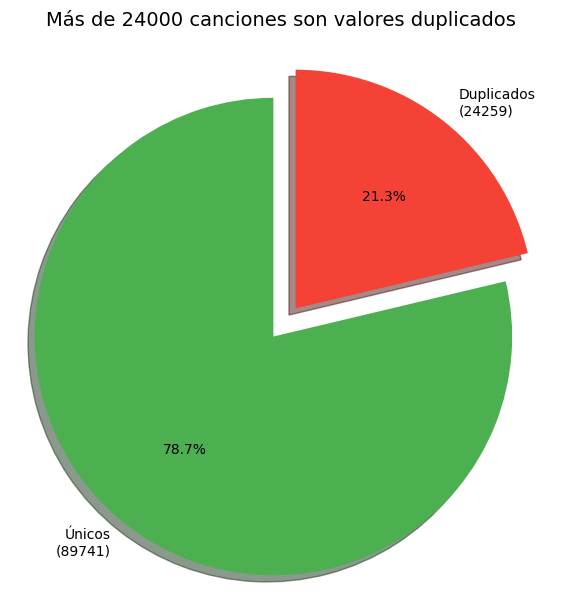

In [ ]:
"""
Script para cuantificar y visualizar registros duplicados.

Este bloque calcula el valor entero exacto de las filas repetidas
basándose en un identificador (track_id). Posteriormente, genera un gráfico de torta que
expone simultáneamente los valores absolutos y sus proporciones
porcentuales para facilitar la auditoría de los datos.
"""

# 1. Calcular los valores enteros exactos
total_duplicados = int(df.duplicated(subset=['track_id']).sum())
total_unicos = int(len(df) - total_duplicados)



# 3. Configurar los parámetros del gráfico
valores = [total_unicos, total_duplicados]
# Integrar el valor entero directamente en la leyenda visual
etiquetas = [f'Únicos\n({total_unicos})', f'Duplicados\n({total_duplicados})']
colores = ['#4CAF50', '#F44336']
desfase = (0, 0.15)

# 4. Construir el gráfico de torta
plt.figure(figsize=(7, 7))
plt.pie(valores,
        labels=etiquetas,
        colors=colores,
        autopct='%1.1f%%',
        explode=desfase,
        startangle=90,
        shadow=True)

# 5. Personalización del lienzo
plt.title("Más de 24000 canciones son valores duplicados", fontsize=14, pad=20)
plt.axis('equal')
plt.show()

### Justificación Técnica: Eliminación de Duplicados por `track_id`

Mantener esta enorme cantidad de registros duplicados (más de 24.000) distorsiona por completo la realidad matemática de nuestro conjunto de datos. Entrenar un algoritmo o modelo estadístico con filas idénticas genera un problema crítico conocido como sobreajuste (*overfitting*).

**¿Por qué fallan los patrones y las métricas se vuelven irreales?**
Al tener una misma canción repetida múltiples veces (conservando sus mismas métricas acústicas de volumen, duración, etc.) solo por una variación en la etiqueta de su género, terminamos engañando al algoritmo. En lugar de aprender el patrón general de comportamiento de los datos, obligamos al modelo a "memorizar" artificialmente estos registros repetidos. Esto hará que el modelo rinda excelente en nuestras pruebas internas, pero fracase por completo al intentar predecir datos nuevos en el mundo real.

**La decisión analítica:**
Para proteger las métricas globales y evitar esta redundancia, la estrategia de ingeniería de datos correcta es ejecutar la eliminación de estas anomalías estructurales, borrando las filas redundantes y preservando únicamente la primera ocurrencia de cada `track_id`.

Asumimos el costo de perder algunas clasificaciones secundarias en la columna del género de la canción, pero a cambio garantizamos un dataset honesto y balanceado. De esta forma, aseguramos que el modelo detecte los verdaderos patrones del éxito musical sin sesgos ni trampas algorítmicas.

In [ ]:
# 1. Eliminar duplicados indicando estrictamente la columna de referencia
df.drop_duplicates(subset=['track_id'], keep='first', inplace=True)

# 2. Resetear el índice del DataFrame para mantener el orden secuencial
df.reset_index(drop=True, inplace=True)

print("Limpieza estructural completada con éxito.")

Limpieza estructural completada con éxito.


In [ ]:
# variables numericas
df_numericas = df.select_dtypes(include=['int64', 'float64'])
df_numericas.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,89741.000000,8.974100e+04,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000
mean,33.198438,2.291418e+05,0.562166,0.634458,5.283549,-8.499004,0.636966,0.087442,0.328289,0.173413,0.216970,0.469477,122.058316,3.897427
std,20.580824,1.129477e+05,0.176691,0.256605,3.559897,5.221490,0.480877,0.113277,0.338321,0.323848,0.194884,0.262864,30.117532,0.453435
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,1.730400e+05,0.450000,0.457000,2.000000,-10.322000,0.000000,0.036000,0.017100,0.000000,0.098200,0.249000,99.264000,4.000000
50%,33.000000,2.132930e+05,0.576000,0.676000,5.000000,-7.185000,1.000000,0.048900,0.188000,0.000058,0.132000,0.457000,122.013000,4.000000
75%,49.000000,2.642930e+05,0.692000,0.853000,8.000000,-5.108000,1.000000,0.085900,0.625000,0.097600,0.279000,0.682000,140.077000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


### Análisis Estadístico de las Variables Numéricas

Al leer la tabla generada por `.describe()`, podemos traducir estos números fríos en conclusiones claras sobre la "anatomía" de las canciones en esta muestra de Spotify:

*   **El éxito es difícil de alcanzar (`popularity`):** Aunque el puntaje va del 0 al 100, el promedio (mean) general es bastante bajo, rondando los 33 puntos. Esto significa que el catálogo está lleno de canciones poco conocidas, y los éxitos masivos mundiales son la minoría.

*   **La confirmación de los datos extremos (`duration_ms`):** El promedio de una canción es de aproximadamente 229.000 milisegundos (casi 4 minutos). Sin embargo, el valor máximo (`max`) supera los 5.2 millones (más de 80 minutos). Esto comprueba matemáticamente la existencia de los valores atípicos (*outliers*) extremos que detectamos en los gráficos anteriores.

*   **La regla del 75% (`speechiness` e `instrumentalness`):** Si miramos la fila del 75%, vemos que la gran mayoría de las canciones tienen valores muy bajos en ambas características (menos de 0.1). Esto indica que el catálogo normal es música cantada. Sin embargo, sus valores máximos llegan a casi 1.0, demostrando que existe un pequeño nicho de pistas puramente instrumentales o de voz pura (como podcasts) que alargan la distribución hacia la derecha.

*   **Un catálogo orientado al baile (`danceability` y `energy`):** Los valores promedio y las medianas (el 50%) de ambas variables superan el 0.5. Esto nos confirma que la plataforma está fuertemente poblada por pistas comerciales, dinámicas y enérgicas.

*   **El comportamiento del volumen (`loudness`):** Al medirse matemáticamente en decibeles, sus valores son negativos. La gran mayoría se agrupa entre los -10 y -5 dB (un volumen estándar), pero el registro mínimo (`min`) cae abruptamente hasta los -49.5 dB, justificando la larga cola (sesgo a la izquierda).

Deberiamos llevar duration_ms a minutos

In [ ]:
# variables categoricas
df_categorias = df.select_dtypes(include=['object'])
df_categorias.describe()

,track_id,artists,album_name,track_name,track_genre
count,89741,89740,89740,89740,89741
unique,89741,31437,46589,73608,113
top,2hETkH7cOfqmz3LqZDHZf5,George Jones,The Complete Hank Williams,Rockin' Around The Christmas Tree,acoustic
freq,1,260,110,48,1000


### Análisis Descriptivo de las Variables Categóricas (Texto)

Al evaluar la tabla generada por `.describe()` para nuestras variables de texto, descubrimos los siguientes patrones y alertas sobre la "identidad" de las canciones:

*   **Éxito en la limpieza (`track_id`):** Vemos que hay 89.741 filas en total (`count`) y exactamente 89.741 valores únicos (`unique`). Esto es una excelente noticia: confirma matemáticamente que nuestra eliminación previa de duplicados fue perfecta y ya no hay canciones repetidas.

*   **Alerta de datos faltantes (`count` disparejo):** Si observamos las columnas `artists`, `album_name` y `track_name`, su conteo es de 89.740 (exactamente uno menos que el total). Esto confirma la existencia de **1 fila con valores nulos** (sin nombre ni artista) que ya habíamos detectado en la inspección inicial y que deberemos borrar antes de entrenar el modelo.

*   **Un catálogo muy diverso (`artists`):** Existen 31.437 artistas únicos en esta muestra. El artista con mayor presencia (`top`) es la leyenda del country *George Jones*, aportando 260 canciones (`freq`) a nuestro dataset limpio.

*   **El fenómeno de los nombres repetidos (`track_name`):** Aunque tenemos casi 90 mil canciones únicas, solo hay 73.608 títulos distintos. Esto significa que muchos artistas usan los mismos nombres para sus canciones o hacen *covers*. El caso más extremo es *"Rockin' Around The Christmas Tree"*, un título que aparece 48 veces cantado por distintos intérpretes o en distintas versiones.

*   **La escena musical (`track_genre`):** El catálogo está dividido en 113 géneros musicales únicos. Tras nuestra limpieza de duplicados, el género que logró retener la mayor cantidad de canciones (`top`) es el *acoustic*, con 1.000 pistas.

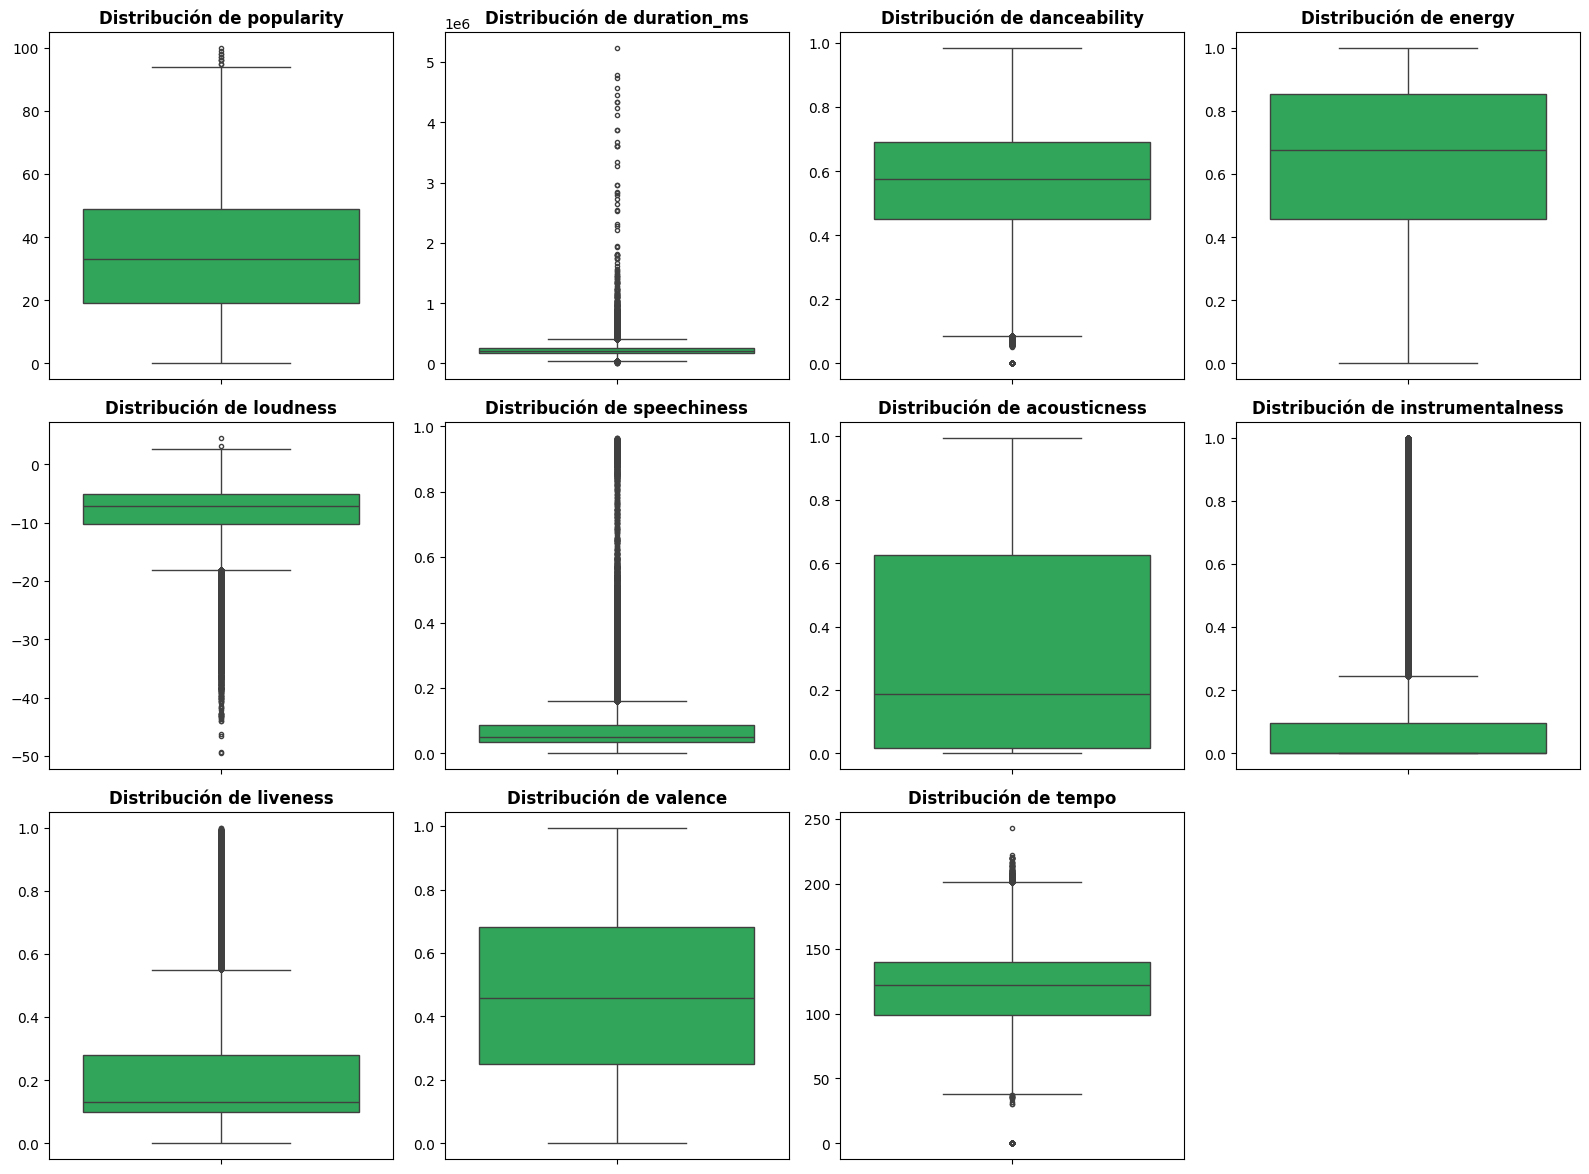

In [ ]:
# 1. Seleccionar numéricas (se recomienda ignorar 'Unnamed: 0' por ser un índice)
df_numericas = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Unnamed: 0', 'mode', 'time_signature', 'key'], errors='ignore')

# 2. Calcular dinámicamente el tamaño de la cuadrícula
columnas = df_numericas.columns
num_cols = len(columnas)
filas = math.ceil(num_cols / 4) # Máximo 4 gráficos por fila

# 3. Configurar el lienzo principal
fig, axes = plt.subplots(nrows=filas, ncols=4, figsize=(16, 4 * filas))
axes = axes.flatten() # Aplanar el arreglo para iterar fácilmente

# 4. Generar un boxplot para cada variable
for i, col in enumerate(columnas):
    sns.boxplot(y=df_numericas[col], ax=axes[i], color='#1DB954', fliersize=3)
    axes[i].set_title(f'Distribución de {col}', fontweight='bold')
    axes[i].set_ylabel('')

# 5. Apagar o limpiar los lienzos sobrantes si la cuadrícula no es exacta
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Mostrar el resultado final de forma ordenada
plt.tight_layout()
plt.show()

### Conclusiones Visuales: Boxplots vs. Estadística (.describe)

Al contrastar estos diagramas de caja con nuestra tabla estadística previa, confirmamos visualmente la "anatomía" de nuestro catálogo musical:

1.  **La confirmación de los datos extremos (Colas hacia arriba):**
    Variables como `duration_ms`, `speechiness`, `instrumentalness` y `liveness` muestran una "caja" muy aplastada en la parte inferior y una larguísima línea de puntos negros que se dispara hacia arriba. Esto ilustra exactamente lo que vimos en el `.describe()`: la enorme mayoría de las canciones tienen valores bajísimos, pero existen casos raros (como pistas de 80 minutos o podcasts de pura voz) que generan esos atípicos severos (*outliers*).

2.  **El caso inverso del volumen (`loudness`):**
    Al revés que las variables anteriores, la caja del volumen está concentrada en la parte superior (cerca del 0 dB), pero suelta una estela de puntos hacia abajo. Esto demuestra visualmente por qué nuestro valor mínimo (`min`) caía hasta los -49.5 dB: existen pistas inusualmente silenciosas que arrastran la distribución hacia la izquierda.

3.  **Las variables "Saludables" (Distribución simétrica):**
    Métricas como `popularity`, `danceability`, `valence` y `tempo` presentan cajas bien proporcionadas. La línea que las atraviesa (que equivale exactamente al 50% o Mediana de nuestra tabla estadística) está bastante centrada. Esto significa que tienen un comportamiento equilibrado y estable, ideal para que los algoritmos aprendan patrones sin confundirse.



### Análisis de Distribución y Sesgo (Deducido desde Boxplots)

A partir de los diagramas de caja, podemos inferir la forma de la campana de Gauss (distribución normal) para cada variable y diagnosticar su sesgo. El sesgo indica hacia dónde se alarga la "cola" de los datos, lo cual es crítico porque las anomalías extremas pueden destruir la estabilidad de algoritmos basados en regresiones lineales.

*   **Sesgo a la Derecha (Asimetría Positiva):**
    *   **Variables:** `duration_ms`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`.
    *   **Forma en la campana:** El pico (la gran mayoría de los datos) se concentra a la izquierda en los valores muy bajos, y se genera una larga cola arrastrada hacia la derecha.
    *   **Significado:** La mayoría de las canciones en Spotify tienen valores mínimos en estas métricas (ej. son muy poco instrumentales o habladas), pero existen unas pocas excepciones extremadamente altas que generan ruido como valores atípicos (*outliers*).

*   **Sesgo a la Izquierda (Asimetría Negativa):**
    *   **Variables:** `loudness` (muy marcado), `danceability` (leve), `energy` (leve).
    *   **Forma en la campana:** El pico de los datos está acumulado a la derecha (valores altos), con una cola alargada hacia la izquierda.
    *   **Significado:** Casi todo el catálogo comercial tiene un volumen (`loudness`) alto y está masterizado con mucha energía. Las excepciones son pistas inusualmente silenciosas o acústicas, representadas por los *outliers* inferiores.

*   **Distribución Simétrica (Campana Equilibrada):**
    *   **Variables:** `popularity`, `valence`, `tempo`, `key`.
    *   **Forma en la campana:** Se asemejan más a una campana de Gauss tradicional. La línea de la mediana está centrada y los "bigotes" del gráfico son proporcionales en ambos lados.
    *   **Significado:** Los datos se distribuyen equitativamente alrededor de su valor medio, siendo ideales para modelos predictivos sin necesidad de transformaciones drásticas.



# Medidas de correlaccion

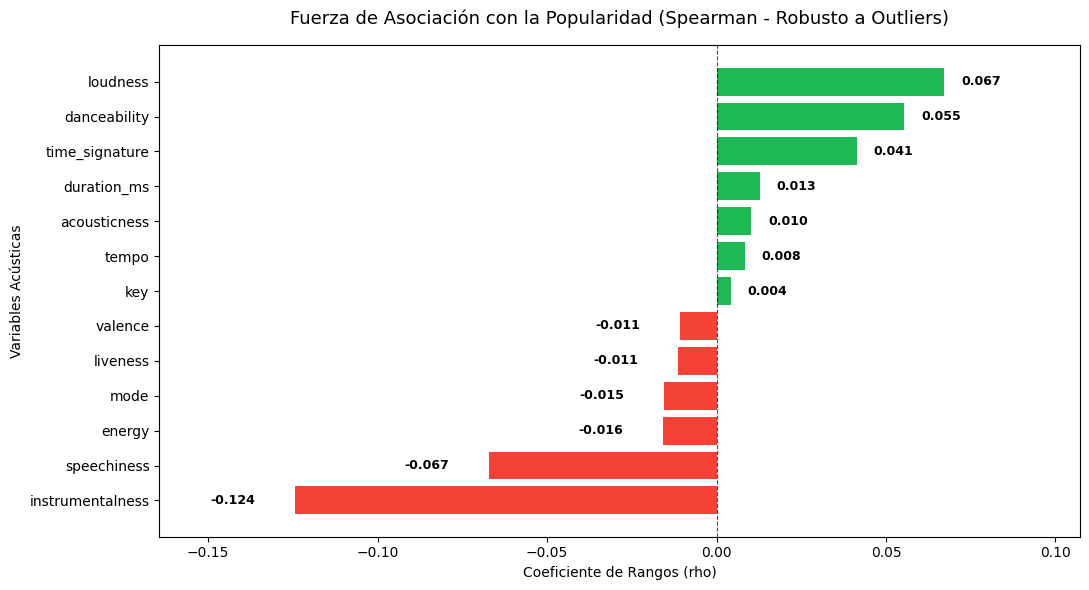

In [ ]:
"""
Script para calcular y proyectar la correlación de Spearman respecto a 'popularity'.

Propósito:
Evalúa la relación monótona entre cada variable acústica y el éxito comercial
('popularity') utilizando el coeficiente de Spearman. Este método es ideal y
robusto ante la presencia de valores atípicos (outliers) severos detectados
en las variables del dataset de Spotify.

El script genera una tabla de coeficientes y un gráfico de barras horizontales
con los valores numéricos exactos, distinguiendo asociaciones positivas y negativas.
"""

# 1. Selección de variables numéricas relevantes (excluyendo el índice técnico)
cols_num = df.select_dtypes(include=['int64', 'float64']).columns.drop('Unnamed: 0', errors='ignore')

# 2. Cálculo de correlación de Spearman contra la variable objetivo
corr_spearman = df[cols_num].corr(method='spearman')['popularity'].drop('popularity').sort_values(ascending=False)


# 4. Construcción del gráfico de barras horizontales divergentes
plt.figure(figsize=(11, 6))

# Paleta condicional: verde para asociaciones positivas, rojo para negativas
colores = ['#1DB954' if val >= 0 else '#F44336' for val in corr_spearman.values]
barras = plt.barh(corr_spearman.index, corr_spearman.values, color=colores, edgecolor='none')

# Línea de referencia vertical en el cero absoluto
plt.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

# Iterar sobre cada barra geométrica para incrustar el valor numérico exacto
for barra in barras:
    ancho = barra.get_width()
    offset = 0.005 if ancho >= 0 else -0.025
    plt.text(ancho + offset,
             barra.get_y() + barra.get_height() / 2,
             f'{ancho:.3f}',
             va='center',
             fontsize=9,
             fontweight='bold')

# Personalización del lienzo
plt.title("Fuerza de Asociación con la Popularidad (Spearman - Robusto a Outliers)", fontsize=13, pad=15)
plt.xlabel("Coeficiente de Rangos (rho)")
plt.ylabel("Variables Acústicas")
plt.xlim(corr_spearman.min() - 0.04, corr_spearman.max() + 0.04)
plt.gca().invert_yaxis()  # Mantiene la variable con mayor correlación en la parte superior

plt.tight_layout()
plt.show()

### La Popularidad como Fenómeno Multifactorial

La evidencia nos sugiere que la prediccion de la popularidad de una cancion no sigue una tendencia lineal sino exponencial, es decir, la popularidad dependen de varios factores

Al analizar el gráfico de Spearman, observamos que ninguna característica acústica tiene una fuerza de asociación alta con la popularidad (ninguna supera el 0.13 de forma individual). Si existiera una tendencia lineal fuerte, veríamos barras mucho más largas acercándose al 1.0.

Esto nos permite sacar tres conclusiones directas para nuestro proyecto:

1. **Ausencia de un factor único:** El éxito de una canción no se explica por una sola métrica'. Incrementar de forma aislada el volumen (`loudness`) o hacer una pista más bailable (`danceability`) no garantiza que su popularidad suba proporcionalmente.

2. **Múltiples factores simultáneos:** La popularidad es el resultado de cómo interactúan todas estas características acústicas al mismo tiempo, sumado a otros datos como el género musical (`track_genre`).

3. **Justificación del algoritmo:** Debido a que las relaciones individuales son débiles y no siguen una línea recta simple, un modelo estadístico básico (como una Regresión Lineal) tendría un desempeño muy bajo. Esto justifica nuestra decisión de utilizar algoritmos avanzados de Machine Learning (como Random Forest), ya que están diseñados específicamente para combinar múltiples variables y detectar patrones complejos

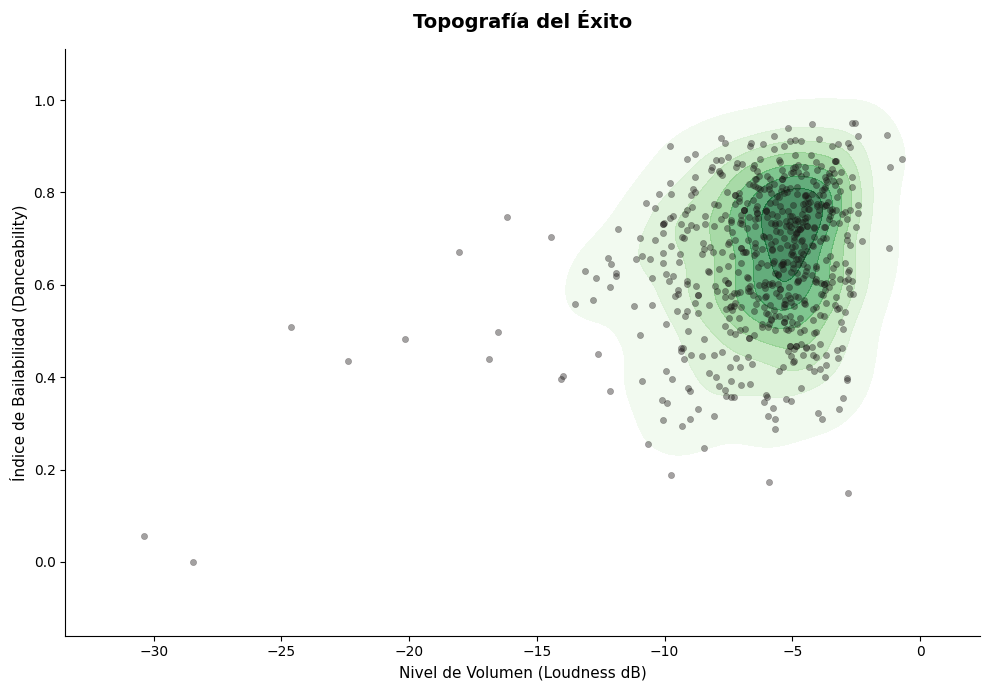

In [ ]:


# 1. Aislar únicamente las canciones de alto rendimiento comercial
df_hits = df[df['popularity'] >= 80].copy()

# 2. Configurar el lienzo principal
plt.figure(figsize=(10, 7))

# 3. Dibujar el mapa de densidad para visualizar el "núcleo" multifactorial
# Esto agrupa los puntos creando zonas topográficas donde se concentra el éxito
sns.kdeplot(
    data=df_hits,
    x='loudness',
    y='danceability',
    fill=True,
    cmap='Greens',
    alpha=0.7,
    thresh=0.05,
    levels=8
)

# 4. Superponer las canciones individuales como puntos translúcidos
sns.scatterplot(
    data=df_hits,
    x='loudness',
    y='danceability',
    color='#191414',
    alpha=0.4,
    s=20,
    edgecolor=None
)

# 5. Personalización estética general
plt.title("Topografía del Éxito", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Nivel de Volumen (Loudness dB)", fontsize=11)
plt.ylabel("Índice de Bailabilidad (Danceability)", fontsize=11)

# 6. Limpiar ruido visual eliminando bordes innecesarios
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Eliminación de variable

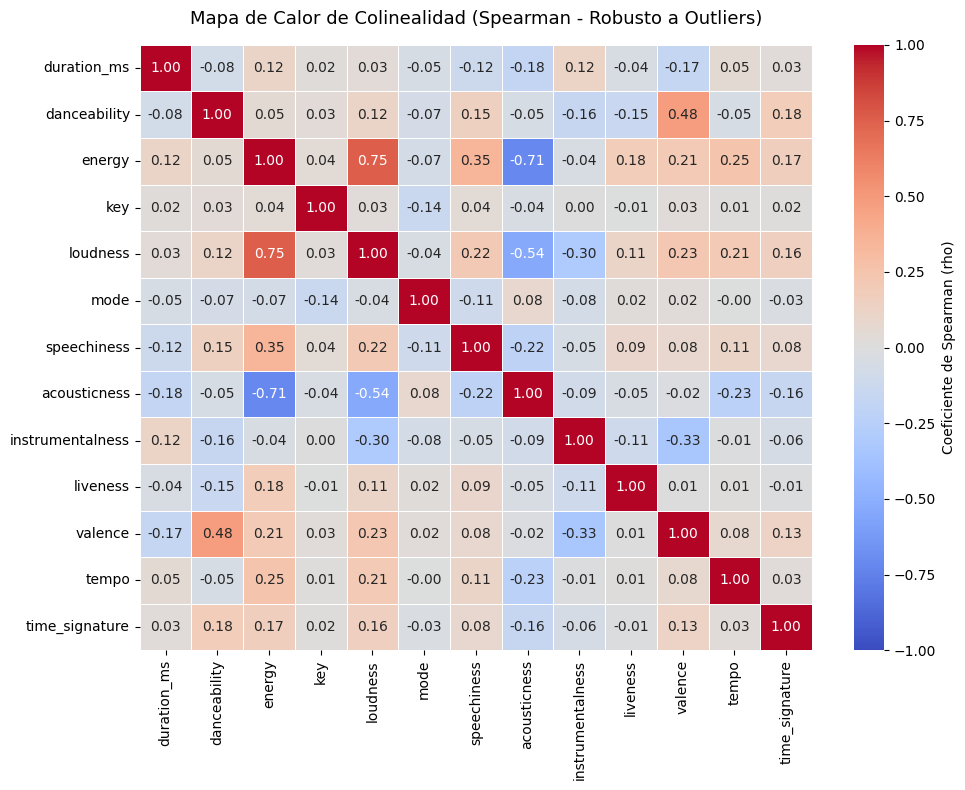

In [ ]:
"""
Script para generar un Mapa de Calor (Heatmap) de colinealidad.

Propósito:
Calcula la matriz de correlación utilizando el coeficiente de rangos de Spearman
exclusivamente sobre las variables numéricas predictoras. Se selecciona Spearman
en lugar de Pearson debido a su robustez matemática frente a los valores atípicos
(outliers) extremos detectados previamente en el dataset.

Su objetivo es detectar visualmente la multicolinealidad, identificando qué
variables independientes presentan alta redundancia entre sí (por ejemplo, |rho| > 0.75).
Esto fundamenta la decisión de eliminar características superpuestas (como 'energy')
antes de entrenar modelos predictivos complejos, evitando su desestabilización.
"""

# 1. Seleccionar únicamente las variables numéricas predictoras (excluyendo identificadores y el target)
cols_predictoras = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Unnamed: 0', 'popularity'], errors='ignore')

# 2. Calcular la matriz de correlación robusta a outliers
matriz_colinealidad = cols_predictoras.corr(method='spearman')

# 3. Configurar y dibujar el mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_colinealidad,
            annot=True,          # Muestra el coeficiente numérico dentro de cada celda
            cmap='coolwarm',     # Paleta divergente (azul para negativo, rojo para positivo)
            fmt=".2f",           # Redondea a dos decimales
            vmin=-1, vmax=1,     # Escala fija de correlación
            linewidths=0.5,      # Líneas divisorias entre celdas
            cbar_kws={'label': 'Coeficiente de Spearman (rho)'})

# 4. Personalización del gráfico
plt.title("Mapa de Calor de Colinealidad (Spearman - Robusto a Outliers)", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

### Análisis de Multicolinealidad y Redundancia de Variables (Spearman)

Al evaluar el Mapa de Calor de Spearman, buscamos correlaciones altas (positivas o negativas) que superen el umbral crítico de 0.75. Introducir variables que prácticamente explican lo mismo genera **multicolinealidad**, lo cual crea redundancia y desestabiliza el entrenamiento de los algoritmos de Machine Learning.

**Diagnóstico del Dataset:**

1. **El conflicto crítico `energy` vs `loudness` ( = 0.75):**
   * **Problema:** Existe una correlación positiva severa. Las pistas con mayor volumen promedio (`loudness`) son rankeadas casi idénticamente como las más enérgicas (`energy`). Estas dos columnas están solapadas y aportan información matemática duplicada al modelo.
   * **Acción:** Para evitar confundir al algoritmo, **debemos eliminar una de las dos**.

2. **El conflicto secundario `energy` vs `acousticness` ( = -0.71):**
   * **Problema:** Presentan una fortísima correlación inversa. Las pistas altamente acústicas carecen casi por completo de energía, lo que vuelve a generar un conflicto de redundancia con la variable `energy`.

3. **Correlaciones moderadas (Ej. `danceability` vs `valence`  = 0.48 o `loudness` vs `acousticness`  = -0.54):**
   * **Veredicto:** Son asociaciones lógicas del mundo musical y **no son lo mismo**. Aportan patrones únicos, por lo que **se deben conservar**. Los modelos predictivos basados en árboles (como Random Forest) utilizarán estas variables juntas para descubrir interacciones complejas.

**Conclusión Operativa y Decisión de Purga:**
Para proteger la integridad del modelo, **se procederá a eliminar la columna `energy`**. Al borrar esta única característica, resolvemos simultáneamente su solapamiento crítico tanto con `loudness` como con `acousticness`, dejando una matriz predictora mucho más limpia, independiente y estable.

Variables a eliminar:
* Energy, por problemas de multicolinealidad
* unnamed: 0, porque no tiene valor predictivo
* track_id, porque no tiene valor predictivo y solo se usó para tratar duplicados

# Ingenieria de caracteristicas, visualizacion

In [ ]:
"""
Script de Ingeniería de Características con objetivo meramente visual.

Funcionalidad:
Crea una copia aislada del dataset original (df_viz) y utiliza operaciones
vectorizadas (np.where) para traducir rápidamente las métricas numéricas en
etiquetas de texto fáciles de leer (por ejemplo, transformar un valor > 0.6
en "bailable" o "podcast").

Objetivo:
Preparar los datos para generar gráficos comprensibles para humanos en la
fase exploratoria, protegiendo al mismo tiempo el dataset original (df), el
cual debe mantener sus valores numéricos intactos para que el modelo predictivo
pueda entrenar correctamente.
"""

# 1. Crear una copia independiente del dataset original
# Esto asegura que df (tu data para el modelo) quede intacta.
df_viz = df.copy()

# 2. Ingeniería de Características para Visualización (Cómputo Vectorial)

# Convertir duración a minutos (se divide por 60,000 milisegundos)
df_viz['duration_min'] = df_viz['duration_ms'] / 60000

# Clasificación binaria usando np.where(condición, valor_si_verdadero, valor_si_falso)
df_viz['speechiness_cat'] = np.where(df_viz['speechiness'] > 0.6, 'podcast', 'canción')

df_viz['instrumentalness_cat'] = np.where(df_viz['instrumentalness'] > 0.6, 'solo instrumento', 'instrumento y voces')

df_viz['liveness_cat'] = np.where(df_viz['liveness'] > 0.6, 'en vivo', 'estudio')

df_viz['valence_cat'] = np.where(df_viz['valence'] > 0.6, 'canción feliz', 'canción triste')

df_viz['danceability_cat'] = np.where(df_viz['danceability'] > 0.6, 'bailable', 'no bailable')

# Para variables que ya son 0 o 1 (o booleanas), la lógica es directa:
# 'explicit' es booleana en tu dataset (True/False o 1/0)
df_viz['explicit_cat'] = np.where(df_viz['explicit'] == 1, 'explícita', 'no explícita')

# 'mode' es 1 para mayor y 0 para menor
df_viz['mode_cat'] = np.where(df_viz['mode'] == 1, 'escalas mayores', 'escalas menores')

# 3. Opcional: Eliminar las columnas numéricas originales en este DataFrame de visualización
# para no tener la información duplicada al hacer los gráficos.
columnas_a_borrar = ['duration_ms', 'speechiness', 'instrumentalness', 'liveness',
                     'valence', 'danceability', 'explicit', 'mode']
df_viz.drop(columns=columnas_a_borrar, inplace=True, errors='ignore')

print("Dataset de visualización (df_viz) generado con éxito")
display(df_viz[['duration_min', 'speechiness_cat', 'instrumentalness_cat', 'valence_cat', 'danceability_cat']].head())

Dataset de visualización (df_viz) generado con éxito


,duration_min,speechiness_cat,instrumentalness_cat,valence_cat,danceability_cat
0,3.844433,canción,instrumento y voces,canción feliz,bailable
1,2.493500,canción,instrumento y voces,canción triste,no bailable
2,3.513767,canción,instrumento y voces,canción triste,no bailable
3,3.365550,canción,instrumento y voces,canción triste,no bailable
4,3.314217,canción,instrumento y voces,canción triste,bailable


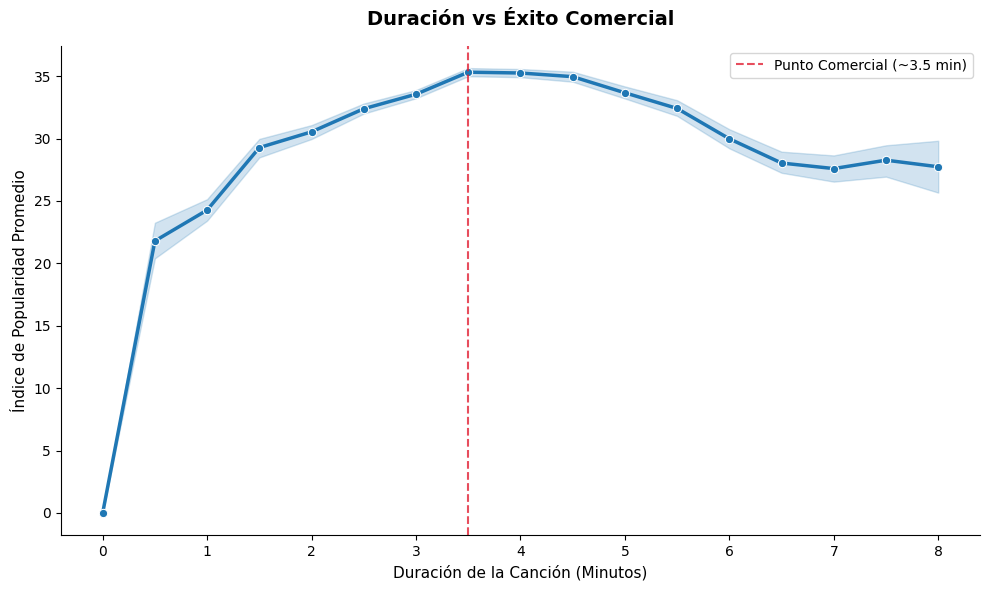

In [ ]:
"""

Este análisis nos permite visualizar y descubrir si existe un "punto optimo"
(por ejemplo, entre los 3 y 4 minutos) donde la popularidad se maximiza,
y si las canciones que superan los cierta cantidad de minutos sufren una
penalización drástica en su éxito

"""
# 1. Crear intervalos (bins) de tiempo para evitar el ruido visual
# Redondeamos la duración a bloques de 0.5 minutos (30 segundos)
df_viz['duration_binned'] = (df_viz['duration_min'] * 2).round() / 2

# 2. Filtrar outliers extremos para no distorsionar el eje X (ej. canciones de más de 8 minutos)
df_tendencia = df_viz[df_viz['duration_min'] <= 8].copy()

# 3. Configurar el lienzo
plt.figure(figsize=(10, 6))

# 4. Crear el gráfico de línea con intervalo de confianza (muestra la dispersión estadística)
sns.lineplot(
    data=df_tendencia,
    x='duration_binned',
    y='popularity',
    linewidth=2.5,
    marker='o',
    markersize=6
)

# 5. Encontrar y marcar automáticamente el "punto optimo" (duración óptima)
punto_maximo = df_tendencia.groupby('duration_binned')['popularity'].mean().idxmax()
plt.axvline(punto_maximo, color='#E22134', linestyle='--', alpha=0.8, linewidth=1.5,
            label=f'Punto Comercial (~{punto_maximo} min)')

# 6. Personalización estética
plt.title("Duración vs Éxito Comercial", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Duración de la Canción (Minutos)", fontsize=11)
plt.ylabel("Índice de Popularidad Promedio", fontsize=11)
plt.legend()

# Limpiar ruido visual de los bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

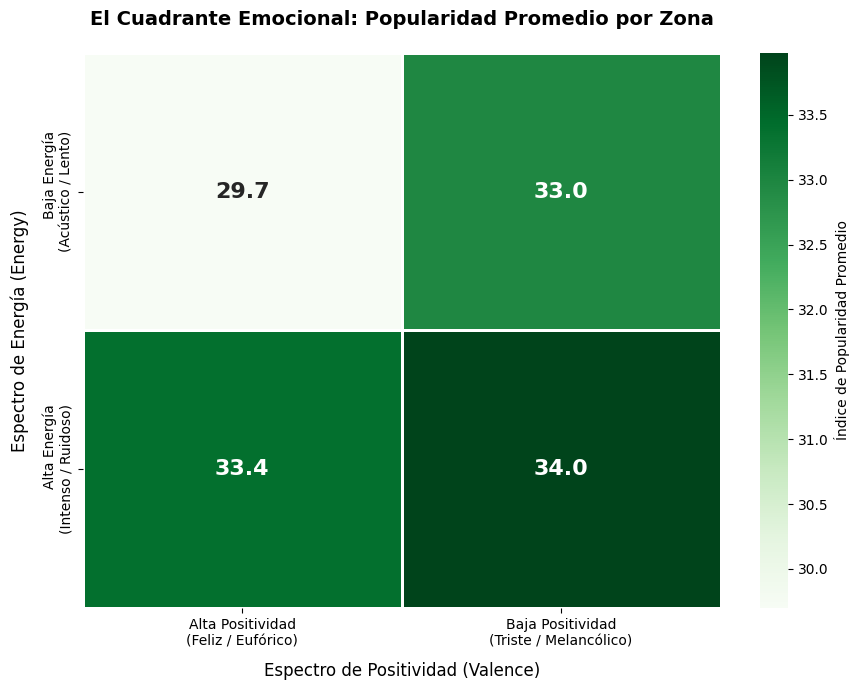

In [ ]:
"""
La popularidad no depende de una sola emoción. Al dividir este
gráfico en cuatro cuadrantes, podemos descubrir si el mercado
actual prefiere canciones eufóricas (alta energía),
melancólicas y lentas (baja energía), o combinaciones
de letras tristes con ritmos muy bailables y enérgicos.
Esto resulta muy valioso para un productor musical

"""

# 1. Crear una copia de las variables de interés desde el dataset original (df)
df_emociones = df[['energy', 'valence', 'popularity']].copy()

# 2. Clasificar en Alta/Baja Energía y Alta/Baja Positividad (Valence)
# Usamos el umbral de 0.5 ya que ambas variables van de 0 a 1
df_emociones['Nivel_Energia'] = np.where(df_emociones['energy'] >= 0.5, 'Alta Energía\n(Intenso / Ruidoso)', 'Baja Energía\n(Acústico / Lento)')
df_emociones['Nivel_Positividad'] = np.where(df_emociones['valence'] >= 0.5, 'Alta Positividad\n(Feliz / Eufórico)', 'Baja Positividad\n(Triste / Melancólico)')

# 3. Crear una tabla dinámica (pivot table) para calcular la popularidad promedio por cuadrante
matriz_cuadrantes = df_emociones.pivot_table(
    values='popularity',
    index='Nivel_Energia',
    columns='Nivel_Positividad',
    aggfunc='mean'
)

# 4. Configurar el lienzo
plt.figure(figsize=(9, 7))

# 5. Dibujar el mapa de calor de 2x2
sns.heatmap(
    matriz_cuadrantes,
    annot=True,          # Muestra el valor numérico en cada celda
    fmt=".1f",           # Formato de un decimal
    cmap='Greens',       # Paleta de colores limpia (verde Spotify)
    cbar_kws={'label': 'Índice de Popularidad Promedio'},
    annot_kws={"size": 16, "weight": "bold"}, # Números grandes y fáciles de leer
    linewidths=2         # Líneas de separación blancas para mayor limpieza
)

# 6. Personalización estética
plt.title("El Cuadrante Emocional: Popularidad Promedio por Zona", fontsize=14, pad=20, fontweight='bold')
plt.xlabel("Espectro de Positividad (Valence)", fontsize=12, labelpad=10)
plt.ylabel("Espectro de Energía (Energy)", fontsize=12, labelpad=10)

# Asegurar que el gráfico se lea de arriba (Alta Energía) hacia abajo (Baja Energía)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

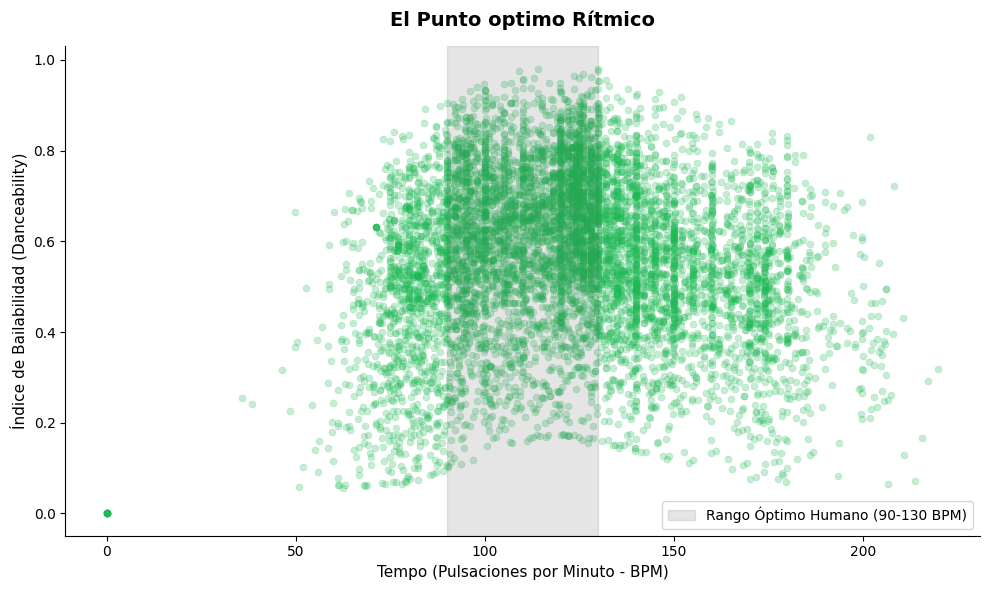

In [ ]:
"""
Es conocido que la fisiología humana responde mejor al baile
cuando las canciones se encuentran en un rango de velocidad
específico, típicamente entre los 90 y 130 BPM (Pulsaciones por Minuto).
Si el algoritmo de Spotify posee una verdadera "Inteligencia Musical",
el índice de bailabilidad (danceability) debería formar una nube de puntos
que alcance su punto más alto justo en ese rango de BPM

"""

# 1. Tomar una muestra representativa (ej. 8,000 registros) del DataFrame original (df)
# Esto evita por completo el ruido visual y el sobretrazado de puntos.
df_muestra_ritmo = df.sample(n=8000, random_state=42)

# 2. Configurar el lienzo
plt.figure(figsize=(10, 6))

# 3. Crear el scatterplot cruzando Tempo vs Bailabilidad
sns.scatterplot(
    data=df_muestra_ritmo,
    x='tempo',
    y='danceability',
    alpha=0.25,         # Transparencia para que la superposición cree zonas más oscuras
    color='#1DB954',    # Verde característico de Spotify
    s=25,               # Tamaño reducido de los puntos para mayor nitidez
    edgecolor=None      # Quitar bordes para limpiar el gráfico
)

# 4. Sombrear el rango bailable de la industria musical (Aprox 90 a 130 BPM)
plt.axvspan(90, 130, color='#535353', alpha=0.15, label='Rango Óptimo Humano (90-130 BPM)')

# 5. Personalización estética general
plt.title("El Punto optimo Rítmico", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Tempo (Pulsaciones por Minuto - BPM)", fontsize=11)
plt.ylabel("Índice de Bailabilidad (Danceability)", fontsize=11)
plt.legend(loc='lower right')

# Limpiar ruido visual de los bordes superior y derecho
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

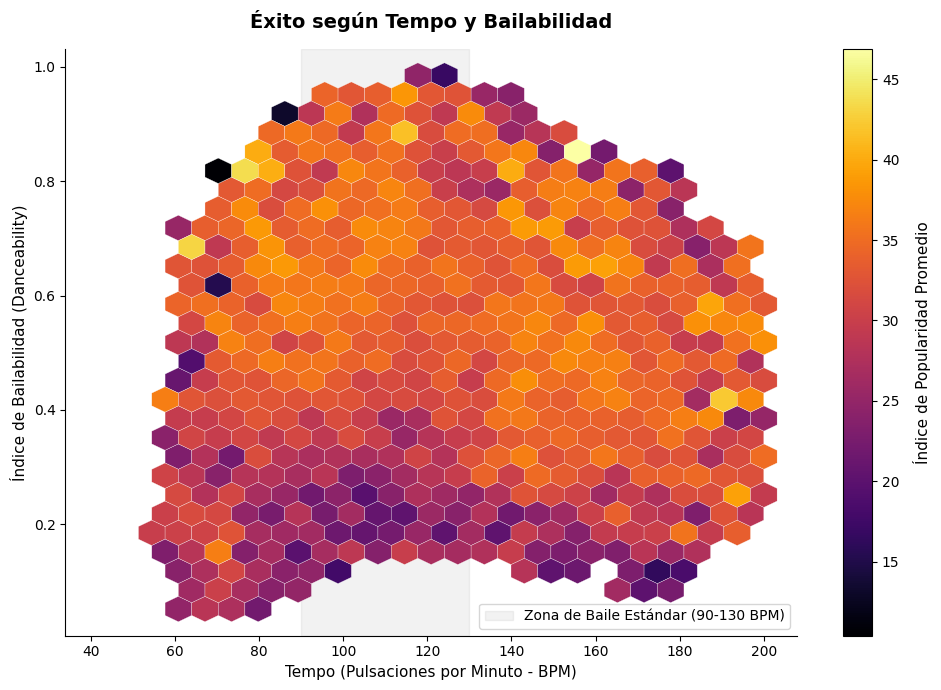

In [ ]:
"""
El gráfico de dispersión anterior demostró dónde se concentra
la mayor cantidad de canciones (el volumen de producción entre 90 y 130 BPM).
Sin embargo, que haya muchas canciones en ese rango no garantiza que sean exitosas.
El Hexbin Plot agrupa esa enorme nube de puntos en "panales hexagonales" y calcula
la popularidad promedio exacta dentro de cada hexágono, asignándole un color de intensidad.
Esto permite descubrir visualmente si el "punto dulce rítmico" (alta bailabilidad y tempo medio)
es verdaderamente el área más rentable y popular dictaminada por los oyentes
o si el éxito comercial se esconde en ritmos atípicos

"""

# 1. Filtrar ligeramente los tempos extremos para enfocar el análisis
df_ritmo_pop = df[(df['tempo'] > 40) & (df['tempo'] < 200)].copy()

# 2. Configurar el lienzo
plt.figure(figsize=(10, 7))

# 3. Crear el Hexbin Plot (Tempo vs Danceability, coloreado por Popularity)
# gridsize controla el tamaño de los hexágonos (mayor número = hexágonos más pequeños)
# reduce_C_function=np.mean asegura que el color represente el PROMEDIO de popularidad en ese hexágono
hexplot = plt.hexbin(
    x=df_ritmo_pop['tempo'],
    y=df_ritmo_pop['danceability'],
    C=df_ritmo_pop['popularity'],
    reduce_C_function=np.mean,
    gridsize=25,
    cmap='inferno', # Paleta perceptualmente uniforme oscura/brillante
    mincnt=10,      # Solo mostrar hexágonos que tengan al menos 10 canciones para evitar datos atípicos
    edgecolors='white',
    linewidths=0.2
)

# 4. Sombrear nuevamente el "Sweet Spot" para ver cómo interactúa con el éxito real
plt.axvspan(90, 130, color='gray', alpha=0.1, zorder=0, label='Zona de Baile Estándar (90-130 BPM)')

# 5. Personalización estética general
plt.title("Éxito según Tempo y Bailabilidad", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Tempo (Pulsaciones por Minuto - BPM)", fontsize=11)
plt.ylabel("Índice de Bailabilidad (Danceability)", fontsize=11)
plt.legend(loc='lower right')

# 6. Añadir la barra de color lateral explicativa
cbar = plt.colorbar(hexplot)
cbar.set_label('Índice de Popularidad Promedio', fontsize=11, labelpad=10)

# Limpiar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Análisis Multivariado: El "Punto Dulce" del Éxito Comercial

Este gráfico de interacción revela patrones complejos que las métricas de correlación simple no pueden detectar. Al cruzar la velocidad (`tempo`), la bailabilidad (`danceability`) y mapear la popularidad promedio mediante colores, descubrimos el verdadero comportamiento del mercado:

1. **La "Zona de Baile Estándar" (90-130 BPM):** Como se observa en la franja sombreada, la mayor concentración de colores cálidos (amarillo y naranja, que indican una popularidad superior a 40 puntos) ocurre estrictamente entre los 90 y 130 BPM. Esto demuestra que la velocidad de la pista sí es relevante, pero únicamente si se encuentra dentro de este rango comercial.

2. **El éxito es una combinación:** Estar dentro de los 90-130 BPM no garantiza el éxito por sí solo. Los hexágonos más brillantes (máxima popularidad) se ubican exclusivamente en la mitad superior de esa franja gris, donde la bailabilidad supera el 0.6. Es la **interacción simultánea** de un tempo moderado con un alto índice de baile lo que maximiza las probabilidades de éxito.

3. **Penalización en los extremos:** Las zonas más oscuras (popularidad menor a 20) dominan toda la parte inferior del gráfico (baja bailabilidad, sin importar el tempo) y los extremos laterales (canciones muy lentas a menos de 80 BPM o muy rápidas a más de 160 BPM).

4. **Justificación del Modelo Predictivo:** En nuestra matriz de Spearman, el `tempo` tenía una correlación casi nula (+0.008)¿. Este gráfico explica por qué: la correlación estadística buscaba una línea recta ascendente, pero el comportamiento real del tempo es un "rango" o clúster centralizado. Esta es la evidencia definitiva de que necesitamos algoritmos avanzados basados en árboles de decisión (como *Random Forest*), ya que son los únicos capaces de detectar estas "zonas de éxito" no lineales para realizar predicciones precisas.

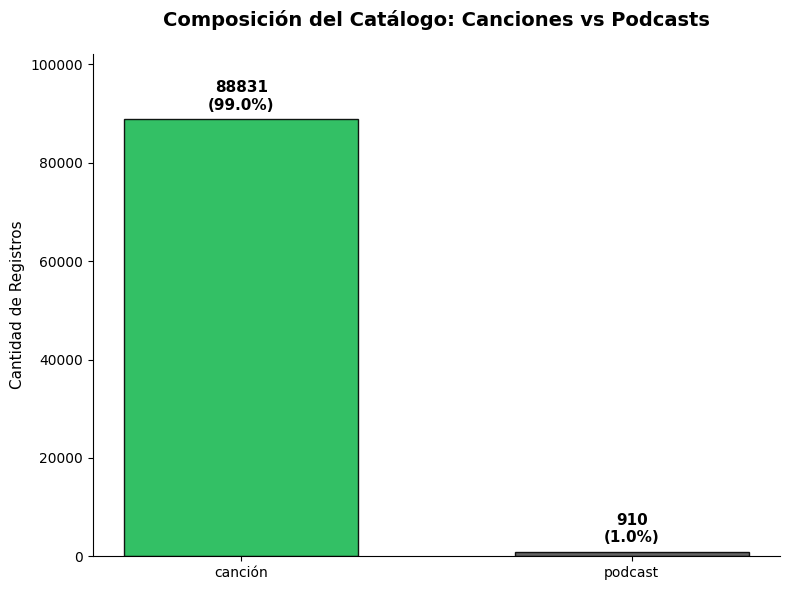

In [ ]:
"""
Script para visualizar la proporción de Canciones vs Podcasts mediante barras.

Propósito:
Utiliza la variable categórica derivada 'speechiness_cat' para generar un
gráfico de barras vertical de estilo minimalista. Calcula las frecuencias
absolutas y relativas (porcentajes) e incrusta ambos datos dinámicamente
sobre cada barra.

Esta técnica visual permite auditar de forma inmediata la composición del
catálogo, demostrando gráficamente la asimetría extrema de esta característica.
"""

# 1. Calcular conteos absolutos y el total para los porcentajes
conteos_speech = df_viz['speechiness_cat'].value_counts()
total_registros = len(df_viz)

# 2. Configurar el lienzo
plt.figure(figsize=(8, 6))

# 3. Asignar colores (Verde Spotify para canciones, Gris oscuro para podcasts)
colores_speech = ['#1DB954' if cat.lower() == 'canción' else '#535353' for cat in conteos_speech.index]

# 4. Crear el gráfico de barras vertical
barras_speech = plt.bar(conteos_speech.index, conteos_speech.values, color=colores_speech, width=0.6, edgecolor='black', alpha=0.9)

# 5. Incrustar valores (entero y porcentaje) en la cima de cada barra
for barra in barras_speech:
    valor_entero = barra.get_height()
    porcentaje = (valor_entero / total_registros) * 100

    # Texto combinado: Entero arriba, Porcentaje abajo
    texto_etiqueta = f"{int(valor_entero)}\n({porcentaje:.1f}%)"

    # Posicionar el texto centrado justo encima de la barra
    plt.text(barra.get_x() + barra.get_width() / 2,
             valor_entero + (total_registros * 0.015), # Margen dinámico hacia arriba
             texto_etiqueta,
             ha='center',
             va='bottom',
             fontsize=11,
             fontweight='bold')

# 6. Personalización estética del gráfico
plt.title("Composición del Catálogo: Canciones vs Podcasts", fontsize=14, pad=20, fontweight='bold')
plt.ylabel("Cantidad de Registros", fontsize=11)
plt.xlabel("")

# Ampliar el límite Y para que el texto superior no choque con el borde
plt.ylim(0, conteos_speech.max() * 1.15)

# Limpiar el "ruido visual" quitando los bordes superior y derecho
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mostrar el resultado final
plt.tight_layout()
plt.show()

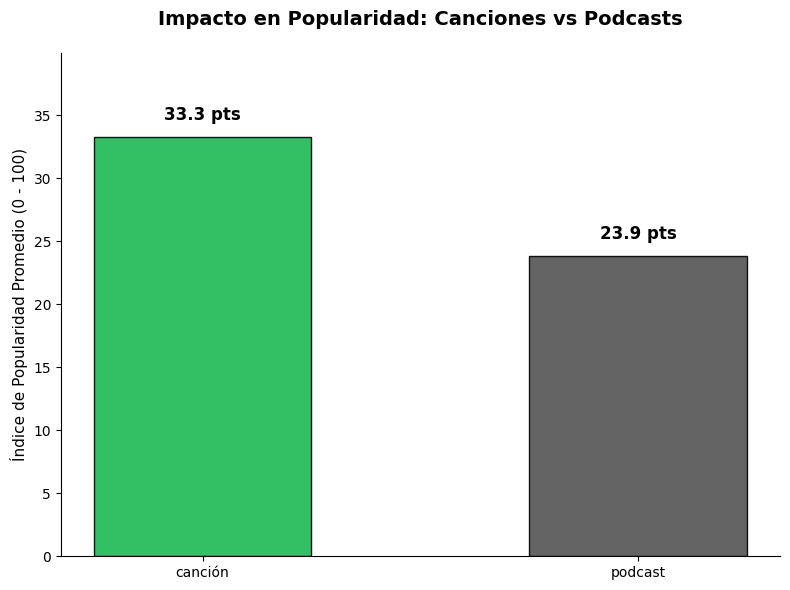

In [ ]:
"""
Script para comparar la popularidad promedio entre Canciones y Podcasts.

Propósito:
Cruza la variable categórica derivada 'speechiness_cat' con la variable
objetivo del proyecto ('popularity'). Calcula el índice de popularidad
promedio para cada grupo y lo visualiza en un gráfico de barras estilizado.

Esto permite auditar gráficamente si el contenido puramente hablado
(podcasts) sufre una penalización comercial en comparación con la música
tradicional dentro del catálogo de Spotify.
"""

# 1. Calcular la popularidad promedio por categoría
# Se agrupa por la nueva columna y se calcula la media matemática
promedios_pop = df_viz.groupby('speechiness_cat')['popularity'].mean()

# 2. Configurar el lienzo
plt.figure(figsize=(8, 6))

# 3. Asignar colores (Verde Spotify para canciones, Gris oscuro para podcasts)
colores_pop = ['#1DB954' if cat.lower() == 'canción' else '#535353' for cat in promedios_pop.index]

# 4. Crear el gráfico de barras vertical
barras_pop = plt.bar(promedios_pop.index, promedios_pop.values, color=colores_pop, width=0.5, edgecolor='black', alpha=0.9)

# 5. Incrustar el valor promedio exacto en la cima de cada barra
for barra in barras_pop:
    valor_promedio = barra.get_height()

    # Posicionar el texto centrado justo encima de la barra
    plt.text(barra.get_x() + barra.get_width() / 2,
             valor_promedio + 1, # Margen dinámico hacia arriba
             f"{valor_promedio:.1f} pts",
             ha='center',
             va='bottom',
             fontsize=12,
             fontweight='bold')

# 6. Personalización estética del gráfico
plt.title("Impacto en Popularidad: Canciones vs Podcasts", fontsize=14, pad=20, fontweight='bold')
plt.ylabel("Índice de Popularidad Promedio (0 - 100)", fontsize=11)
plt.xlabel("")

# Ampliar el límite Y para que el texto superior no choque con el borde
plt.ylim(0, promedios_pop.max() * 1.2)

# Limpiar el "ruido visual" quitando los bordes superior y derecho
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mostrar el resultado final
plt.tight_layout()
plt.show()

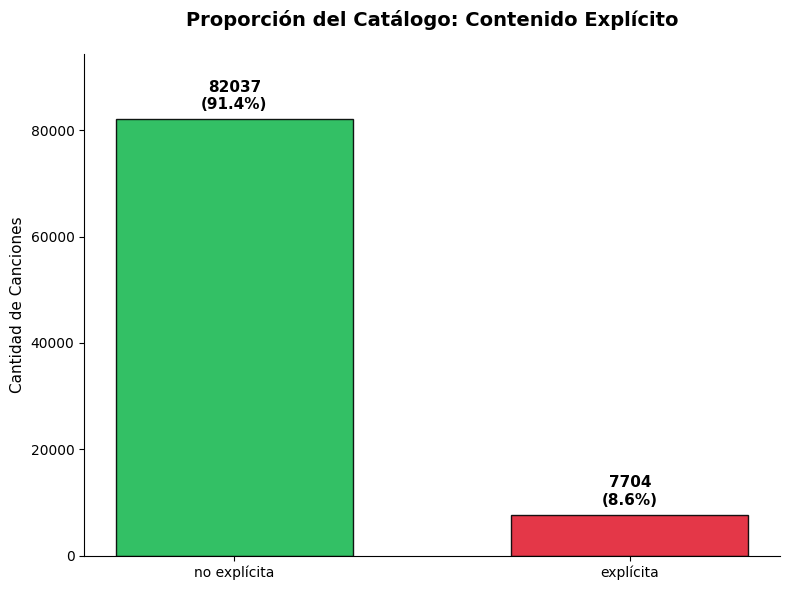

In [ ]:
"""
Script para visualizar la proporción de pistas explícitas mediante barras.

Propósito:
Utiliza la variable categórica 'explicit_cat' para generar un gráfico de
barras vertical estilizado. Calcula las frecuencias absolutas y relativas
(porcentajes) e incrusta ambos datos dinámicamente sobre cada barra.

Esta técnica elimina la necesidad de que el usuario adivine los valores
mirando el eje Y, aportando un valor visual inmediato a la fase de EDA.
"""

# 1. Calcular conteos absolutos y el total para los porcentajes
conteos = df_viz['explicit_cat'].value_counts()
total_pistas = len(df_viz)

# 2. Configurar el lienzo
plt.figure(figsize=(8, 6))

# 3. Asignar colores semánticos (Rojo para explícito, Verde para no explícito)
colores = ['#1DB954' if cat == 'no explícita' else '#E22134' for cat in conteos.index]

# 4. Crear el gráfico de barras vertical
barras = plt.bar(conteos.index, conteos.values, color=colores, width=0.6, edgecolor='black', alpha=0.9)

# 5. Incrustar valores (entero y porcentaje) en la cima de cada barra
for barra in barras:
    valor_entero = barra.get_height()
    porcentaje = (valor_entero / total_pistas) * 100

    # Texto combinado: Entero arriba, Porcentaje abajo
    texto_etiqueta = f"{int(valor_entero)}\n({porcentaje:.1f}%)"

    # Posicionar el texto centrado justo encima de la barra
    plt.text(barra.get_x() + barra.get_width() / 2,
             valor_entero + (total_pistas * 0.015), # Margen dinámico hacia arriba
             texto_etiqueta,
             ha='center',
             va='bottom',
             fontsize=11,
             fontweight='bold')

# 6. Personalización estética del gráfico (hacerlo "más bonito")
plt.title("Proporción del Catálogo: Contenido Explícito", fontsize=14, pad=20, fontweight='bold')
plt.ylabel("Cantidad de Canciones", fontsize=11)
plt.xlabel("") # Se deja en blanco porque las categorías ya son claras

# Ampliar el límite Y para que el texto superior no choque con el borde del gráfico
plt.ylim(0, conteos.max() * 1.15)

# Limpiar el "ruido visual" quitando los bordes superior y derecho del cuadro
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mostrar el resultado
plt.tight_layout()
plt.show()

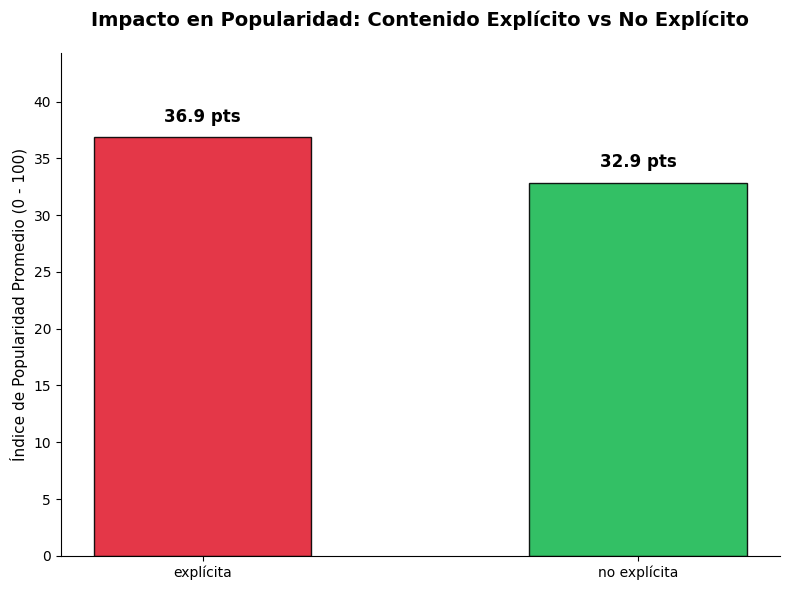

In [ ]:
"""
Script para comparar la popularidad promedio según el contenido explícito.

Propósito:
Cruza la variable categórica 'explicit_cat' con la variable objetivo
('popularity'). Calcula el índice de popularidad promedio para las pistas
con y sin contenido explícito, visualizando el resultado en un gráfico
de barras minimalista.

Esto permite auditar gráficamente si el uso de lenguaje explícito
representa una ventaja comercial o una penalización dentro del catálogo
de Spotify analizado.
"""

# 1. Calcular la popularidad promedio por categoría de contenido explícito
promedios_explicit = df_viz.groupby('explicit_cat')['popularity'].mean()

# 2. Configurar el lienzo
plt.figure(figsize=(8, 6))

# 3. Asignar colores (Verde Spotify para 'no explícita', Rojo para 'explícita')
colores_explicit = ['#E22134' if cat.lower() == 'explícita' else '#1DB954' for cat in promedios_explicit.index]

# 4. Crear el gráfico de barras vertical
barras_explicit = plt.bar(promedios_explicit.index, promedios_explicit.values, color=colores_explicit, width=0.5, edgecolor='black', alpha=0.9)

# 5. Incrustar el valor promedio exacto en la cima de cada barra
for barra in barras_explicit:
    valor_promedio = barra.get_height()

    # Posicionar el texto centrado justo encima de la barra
    plt.text(barra.get_x() + barra.get_width() / 2,
             valor_promedio + 1, # Margen dinámico hacia arriba
             f"{valor_promedio:.1f} pts",
             ha='center',
             va='bottom',
             fontsize=12,
             fontweight='bold')

# 6. Personalización estética del gráfico
plt.title("Impacto en Popularidad: Contenido Explícito vs No Explícito", fontsize=14, pad=20, fontweight='bold')
plt.ylabel("Índice de Popularidad Promedio (0 - 100)", fontsize=11)
plt.xlabel("")

# Ampliar el límite Y para que el texto superior no choque con el borde
plt.ylim(0, promedios_explicit.max() * 1.2)

# Limpiar el ruido visual quitando los bordes superior y derecho
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mostrar el resultado final
plt.tight_layout()
plt.show()

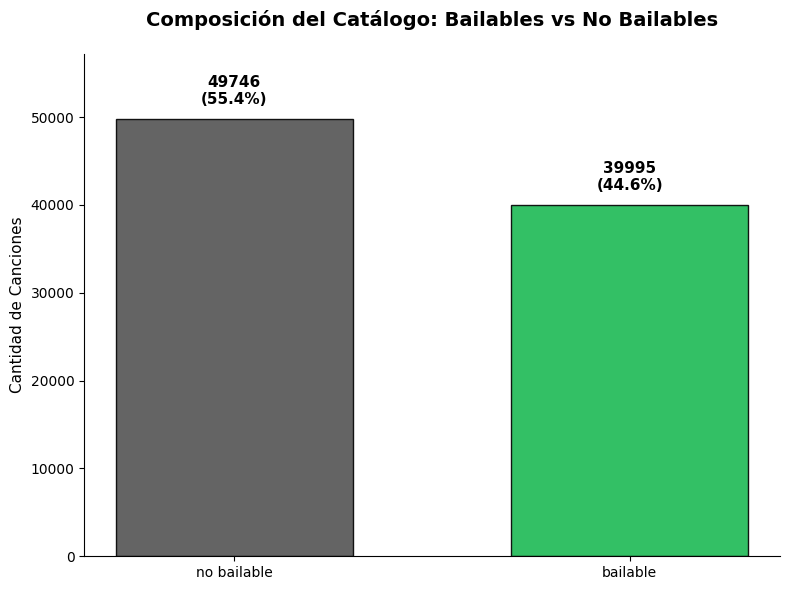

In [ ]:
"""
Script para visualizar la proporción de pistas Bailables vs No Bailables.

Propósito:
Utiliza la variable categórica derivada 'danceability_cat' para generar un
gráfico de barras vertical de estilo minimalista.

Calcula las frecuencias absolutas y relativas (porcentajes) e incrusta ambos
datos dinámicamente sobre cada barra. Esta visualización permite entender
de inmediato la distribución rítmica general del catálogo de Spotify analizado.
"""

# 1. Calcular conteos absolutos y el total para los porcentajes
conteos_dance = df_viz['danceability_cat'].value_counts()
total_registros = len(df_viz)

# 2. Configurar el lienzo
plt.figure(figsize=(8, 6))

# 3. Asignar colores (Verde Spotify para bailable, Gris oscuro para no bailable)
colores_dance = ['#1DB954' if cat.lower() == 'bailable' else '#535353' for cat in conteos_dance.index]

# 4. Crear el gráfico de barras vertical
barras_dance = plt.bar(conteos_dance.index, conteos_dance.values, color=colores_dance, width=0.6, edgecolor='black', alpha=0.9)

# 5. Incrustar valores (entero y porcentaje) en la cima de cada barra
for barra in barras_dance:
    valor_entero = barra.get_height()
    porcentaje = (valor_entero / total_registros) * 100

    # Texto combinado: Entero arriba, Porcentaje abajo
    texto_etiqueta = f"{int(valor_entero)}\n({porcentaje:.1f}%)"

    # Posicionar el texto centrado justo encima de la barra
    plt.text(barra.get_x() + barra.get_width() / 2,
             valor_entero + (total_registros * 0.015), # Margen dinámico hacia arriba
             texto_etiqueta,
             ha='center',
             va='bottom',
             fontsize=11,
             fontweight='bold')

# 6. Personalización estética del gráfico
plt.title("Composición del Catálogo: Bailables vs No Bailables", fontsize=14, pad=20, fontweight='bold')
plt.ylabel("Cantidad de Canciones", fontsize=11)
plt.xlabel("")

# Ampliar el límite Y para que el texto superior no choque con el borde
plt.ylim(0, conteos_dance.max() * 1.15)

# Limpiar el ruido visual quitando los bordes superior y derecho
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mostrar el resultado final
plt.tight_layout()
plt.show()

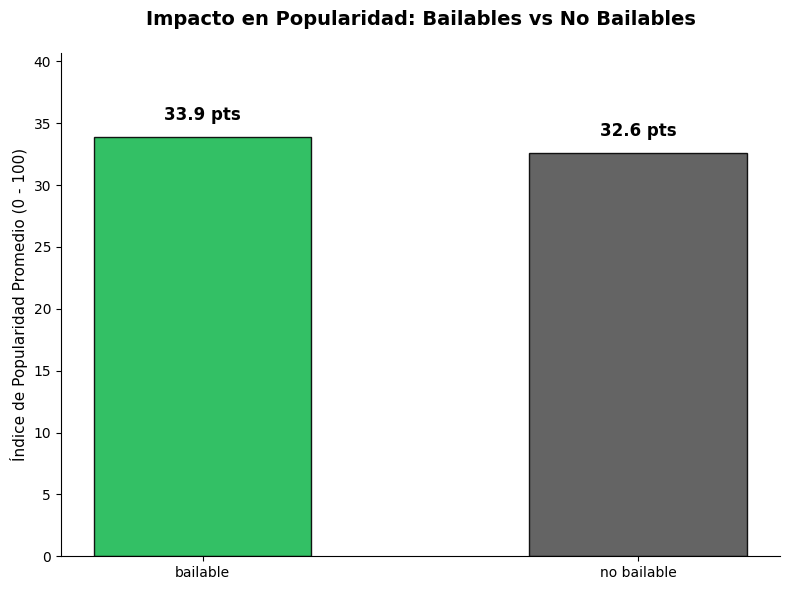

In [ ]:
"""
Script para comparar la popularidad promedio entre pistas Bailables y No Bailables.

Propósito:
Cruza la variable categórica derivada 'danceability_cat' con la variable
objetivo ('popularity'). Calcula el índice de popularidad promedio para
cada grupo y lo visualiza mediante un gráfico de barras minimalista.

Esto permite auditar gráficamente si las canciones orientadas al baile
presentan una ventaja real en su éxito comercial frente a las pistas
menos bailables dentro del catálogo analizado.
"""

# 1. Calcular la popularidad promedio por categoría de bailabilidad
promedios_dance = df_viz.groupby('danceability_cat')['popularity'].mean()

# 2. Configurar el lienzo
plt.figure(figsize=(8, 6))

# 3. Asignar colores (Verde Spotify para bailable, Gris oscuro para no bailable)
colores_dance = ['#1DB954' if cat.lower() == 'bailable' else '#535353' for cat in promedios_dance.index]

# 4. Crear el gráfico de barras vertical
barras_dance = plt.bar(promedios_dance.index, promedios_dance.values, color=colores_dance, width=0.5, edgecolor='black', alpha=0.9)

# 5. Incrustar el valor promedio exacto en la cima de cada barra
for barra in barras_dance:
    valor_promedio = barra.get_height()

    # Posicionar el texto centrado justo encima de la barra
    plt.text(barra.get_x() + barra.get_width() / 2,
             valor_promedio + 1, # Margen dinámico hacia arriba
             f"{valor_promedio:.1f} pts",
             ha='center',
             va='bottom',
             fontsize=12,
             fontweight='bold')

# 6. Personalización estética del gráfico
plt.title("Impacto en Popularidad: Bailables vs No Bailables", fontsize=14, pad=20, fontweight='bold')
plt.ylabel("Índice de Popularidad Promedio (0 - 100)", fontsize=11)
plt.xlabel("")

# Ampliar el límite Y para evitar que el texto choque con el borde superior
plt.ylim(0, promedios_dance.max() * 1.2)

# Limpiar el ruido visual eliminando los bordes superior y derecho
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mostrar el resultado final
plt.tight_layout()
plt.show()

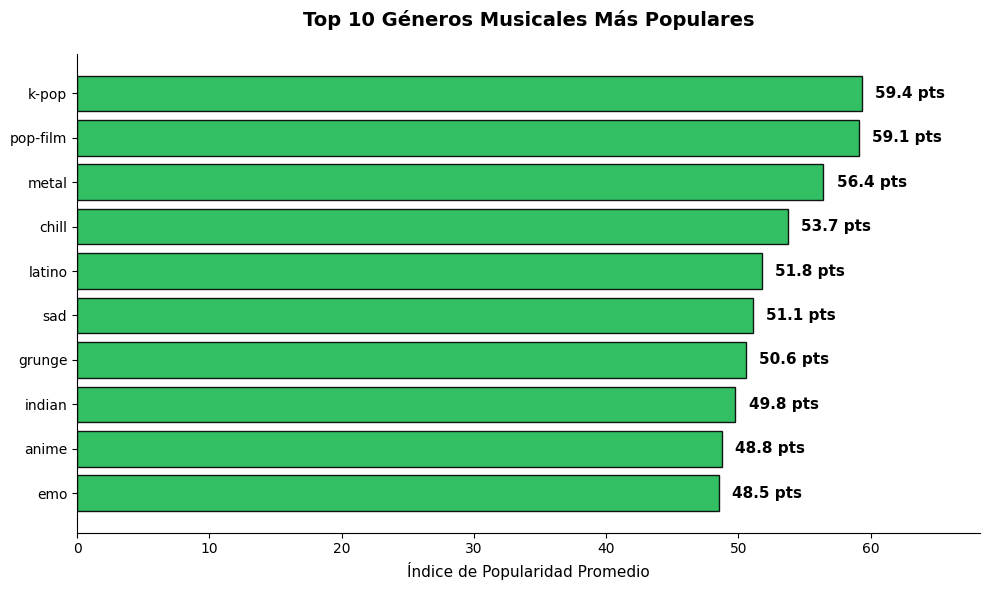

In [ ]:
"""
Script para visualizar los 10 géneros musicales más exitosos.

Propósito:
Agrupa el dataset original por género musical ('track_genre') y calcula la
popularidad promedio. Muestra el Top 10 en un gráfico de barras horizontales
estilizado. Esto demuestra visualmente la importancia de conservar variables
de baja cardinalidad (contexto) para el modelamiento predictivo.
"""

# 1. Agrupar por género, calcular el promedio y extraer los 10 más altos
# Usamos el DataFrame original 'df' ya que tiene la popularidad intacta
top_generos = df.groupby('track_genre')['popularity'].mean().nlargest(10)

# 2. Configurar el lienzo
plt.figure(figsize=(10, 6))

# 3. Crear barras horizontales (Verde Spotify)
barras_gen = plt.barh(top_generos.index, top_generos.values, color='#1DB954', edgecolor='black', alpha=0.9)

# 4. Incrustar los valores exactos al final de cada barra
for barra in barras_gen:
    ancho = barra.get_width()
    plt.text(ancho + 1, # Pequeño margen a la derecha de la barra
             barra.get_y() + barra.get_height() / 2,
             f"{ancho:.1f} pts",
             ha='left',
             va='center',
             fontsize=11,
             fontweight='bold')

# 5. Personalización estética del gráfico
plt.title("Top 10 Géneros Musicales Más Populares", fontsize=14, pad=20, fontweight='bold')
plt.xlabel("Índice de Popularidad Promedio", fontsize=11)
plt.ylabel("")

# Invertir el eje Y para que el género #1 quede en la parte superior
plt.gca().invert_yaxis()

# Ampliar límite X para que el texto no choque con el borde derecho
plt.xlim(0, top_generos.max() * 1.15)

# Limpiar el ruido visual
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

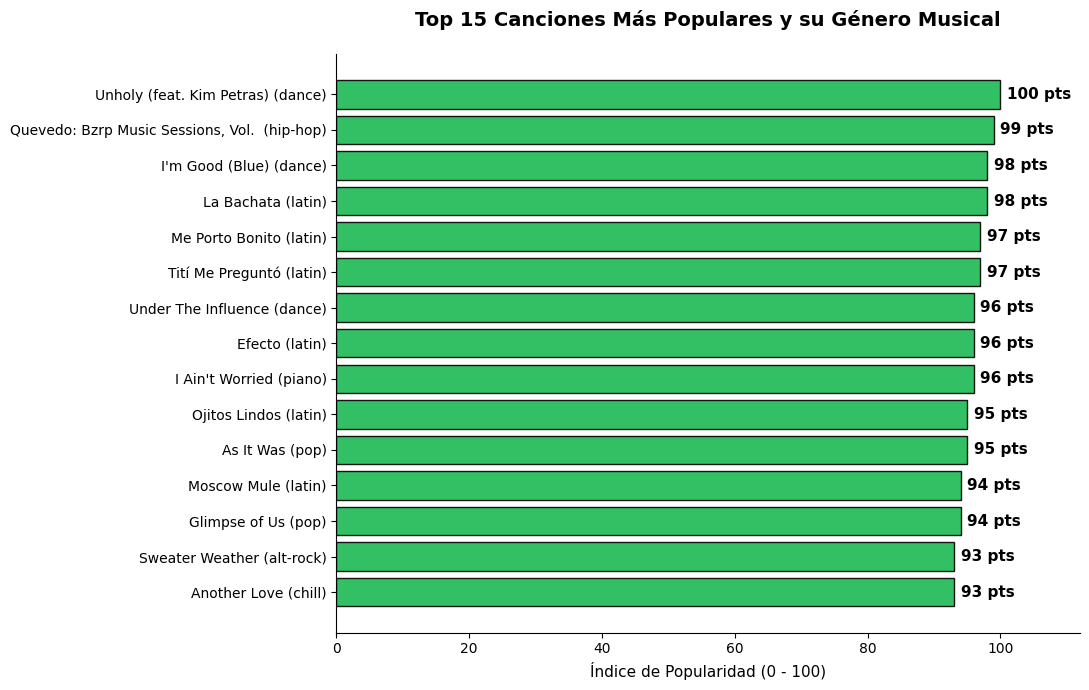

In [ ]:
"""
Script para visualizar las pistas más populares y su contexto de género.

Propósito:
Extrae las 15 pistas con mayor índice de éxito comercial ('popularity')
y combina su título con el género musical ('track_genre') en el eje Y.
Esto permite a la audiencia observar directamente a qué nicho pertenecen
los grandes éxitos del catálogo, reforzando la importancia de conservar
la variable del género para el modelamiento predictivo.
"""

# 1. Extraer el Top 15 de canciones más populares
# Usamos el DataFrame original 'df' para tener la popularidad intacta
top_canciones = df.nlargest(15, 'popularity').copy()

# 2. Crear una etiqueta combinada: "Nombre de la Canción (Género)"
# Recortamos el nombre a 35 caracteres máximo para mantener el gráfico alineado y legible
top_canciones['nombre_corto'] = top_canciones['track_name'].str.slice(0, 35)
top_canciones['etiqueta_visual'] = top_canciones['nombre_corto'] + " (" + top_canciones['track_genre'] + ")"

# 3. Configurar el lienzo
plt.figure(figsize=(11, 7))

# 4. Crear el gráfico de barras horizontales
barras_top = plt.barh(top_canciones['etiqueta_visual'], top_canciones['popularity'], color='#1DB954', edgecolor='black', alpha=0.9)

# 5. Incrustar los valores exactos de popularidad al final de la barra
for barra in barras_top:
    ancho = barra.get_width()
    plt.text(ancho + 1, # Pequeño margen a la derecha
             barra.get_y() + barra.get_height() / 2,
             f"{int(ancho)} pts",
             ha='left',
             va='center',
             fontsize=11,
             fontweight='bold')

# 6. Personalización estética
plt.title("Top 15 Canciones Más Populares y su Género Musical", fontsize=14, pad=20, fontweight='bold')
plt.xlabel("Índice de Popularidad (0 - 100)", fontsize=11)
plt.ylabel("")

# Invertir el eje Y para que el hit #1 quede en la parte superior
plt.gca().invert_yaxis()

# Ampliar límite X para que el texto no choque con el borde derecho
plt.xlim(0, top_canciones['popularity'].max() + 12)

# Limpiar el ruido visual (eliminar bordes superior y derecho)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
"""
Script para extraer el perfil acústico de las 15 pistas más populares.

Propósito:
Utiliza el método .nlargest() para obtener las 15 canciones con mayor
índice de éxito comercial ('popularity'). Luego, filtra las columnas para
mostrar exclusivamente los metadatos identificativos y las métricas
acústicas solicitadas: loudness, danceability, time_signature,
duration_ms, acousticness, tempo y key.

Esto permite una auditoría tabular directa de la "receta sonora"
que compone a los hits actuales del catálogo.
"""

# 1. Definir las columnas exactas que queremos observar
columnas_interes = [
    'track_name', 'artists', 'popularity',
    'loudness', 'danceability', 'time_signature',
    'duration_ms', 'acousticness', 'tempo', 'key'
]

# 2. Extraer el Top 15 general y filtrar por las columnas definidas
# Se utiliza el DataFrame original 'df' que contiene los valores numéricos crudos
top_15_acustico = df.nlargest(15, 'popularity')[columnas_interes]

# 3. Desplegar la tabla para su análisis visual
print("--- Perfil Acústico de las 15 Canciones Más Populares ---")
display(top_15_acustico)

--- Perfil Acústico de las 15 Canciones Más Populares ---


,track_name,artists,popularity,loudness,danceability,time_signature,duration_ms,acousticness,tempo,key
18906,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100,-7.375,0.714,4,156943,0.01300,131.121,2
45781,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99,-5.548,0.621,4,198937,0.01250,128.033,2
18913,I'm Good (Blue),David Guetta;Bebe Rexha,98,-3.673,0.561,4,175238,0.00383,128.040,7
57109,La Bachata,Manuel Turizo,98,-5.329,0.835,4,162637,0.58300,124.980,7
57111,Me Porto Bonito,Bad Bunny;Chencho Corleone,97,-5.105,0.911,4,178567,0.09010,92.005,1
57112,Tití Me Preguntó,Bad Bunny,97,-5.198,0.650,4,243716,0.09930,106.672,5
18905,Under The Influence,Chris Brown,96,-5.529,0.733,4,184613,0.06350,116.992,9
57291,Efecto,Bad Bunny,96,-8.797,0.801,4,213061,0.14100,98.047,7
66009,I Ain't Worried,OneRepublic,96,-5.927,0.704,4,148485,0.08260,139.994,0
57250,Ojitos Lindos,Bad Bunny;Bomba Estéreo,95,-5.745,0.647,4,258298,0.08000,79.928,3


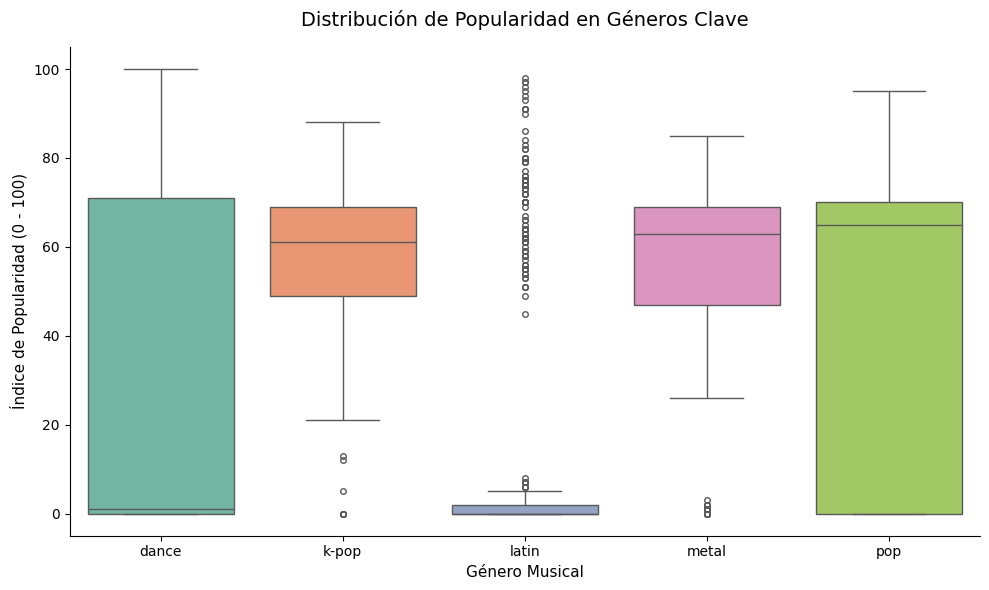

In [ ]:
"""
Script para analizar visualmente la dispersión de la popularidad por género.

Propósito:
Demuestra cómo los "mega-éxitos" (canciones > 90 pts) son en realidad
valores atípicos (outliers) positivos que escapan a la norma de sus propios
géneros musicales (cuyos promedios suelen rondar los 50 pts).

Actualización: Incorpora la sintaxis moderna de Seaborn (hue + legend=False)
para el manejo de paletas de colores.
"""

# 1. Definir una lista con géneros clave a comparar (mezcla de hits y promedios altos)
generos_interes = ['latin', 'pop', 'dance', 'k-pop', 'metal']

# 2. Filtrar el DataFrame original para incluir solo estos géneros
df_analisis_generos = df[df['track_genre'].isin(generos_interes)]

# 3. Configurar el lienzo
plt.figure(figsize=(10, 6))

# 4. Crear el Boxplot (Código Actualizado)
sns.boxplot(data=df_analisis_generos,
            x='track_genre',
            y='popularity',
            hue='track_genre', # Solución al FutureWarning: Asignar 'x' a 'hue'
            legend=False,      # Solución al FutureWarning: Apagar la leyenda
            palette='Set2',
            fliersize=4)       # Tamaño de los puntos atípicos (outliers)

# 5. Personalización estética
plt.title("Distribución de Popularidad en Géneros Clave", fontsize=14, pad=15)
plt.xlabel("Género Musical", fontsize=11)
plt.ylabel("Índice de Popularidad (0 - 100)", fontsize=11)

# Limpiar bordes visuales
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretación Visual: La Anatomía del Éxito por Género

El diagrama de caja  revela realidades comerciales completamente distintas según el género musical, confirmando por qué las canciones más populares del mundo no pertenecen necesariamente a los géneros con el promedio más alto (son outliers) .

1. **El fenómeno `latin` (La fábrica de Outliers):**
   La caja verde grisácea está completamente aplastada contra el 0. Esto significa que el comportamiento "normal" (el 75% de las canciones latinas en este catálogo) es tener una popularidad extremadamente baja. Sin embargo, observamos una gigantesca estela de puntos sueltos que se disparan hasta casi los 100 puntos. Estos son los "mega-éxitos" mundiales. Estadísticamente, son **valores atípicos (outliers)**: anomalías comerciales que escapan por completo a la dura realidad del 99% de los artistas de su propio género.

2. **La consistencia del nicho (`k-pop` y `metal`):**
   A diferencia del género latino, las cajas de estos géneros flotan alto, con sus líneas centrales (medianas) superando los 60 puntos. Esto demuestra matemáticamente la existencia de un nicho de oyentes (fanbase) sumamente leal. Aunque no poseen los "mega-éxitos" de 100 puntos (carecen de outliers en la parte superior), la gran mayoría de sus canciones garantiza un nivel base de popularidad muy alto. Al tener muy poca "basura" o canciones en 0, su promedio general se mantiene en la cima del catálogo.

3. **La extrema desigualdad (`pop` y `dance`):**
   Presentan cajas excepcionalmente altas (alargadas). Esto indica una altísima varianza o desigualdad interna: tienen una gran masa de canciones que nadie escucha (cerca del 0), pero al mismo tiempo una inmensa cantidad de canciones comerciales exitosas, abarcando prácticamente todo el espectro matemático (de 0 a 100) sin que se consideren outliers estadísticos.

**Conclusión para el Modelo Predictivo:**
Este gráfico justifica plenamente por qué no podemos eliminar los outliers de la variable `popularity` ni descartar la columna `track_genre`. Si borramos los puntos atípicos, el modelo jamás podrá predecir un hit mundial latino. El algoritmo necesitará el contexto del género musical para entender si está evaluando una canción de un mercado consistente (`metal`) o de un mercado de "todo o nada" (`latin`).

# Ingenieria de caracteristicas, preparacion del modelo

## sin outliers


In [ ]:
"""
Script para la preparación final: Separación del Target, purga de variables
y clasificación estructural (Cuantitativas vs Cualitativas).

Tratamiento de Datos:
1. Aislamiento del Target: Se extrae 'popularity' como nuestro vector objetivo (y).

2. Purga de Variables (Feature Selection):
   - Se eliminan identificadores únicos y textos de alta cardinalidad ('Unnamed: 0',
     'track_id', 'artists', 'album_name', 'track_name') ya que no aportan patrones
     generalizables y provocan sobreajuste (overfitting).

   - Se elimina 'energy' por presentar multicolinealidad severa frente a 'loudness',
     evitando redundancia en el algoritmo predictivo.

Clasificación Analítica vs Tipo de Dato (Dtype):
En Machine Learning, el tipo informático de una columna (ej. int64) no siempre
define su naturaleza analítica.
- Variables como 'key' (tonalidad), 'mode' (escala) o 'time_signature' (compás)
  están escritas con números, pero conceptualmente son características CUALITATIVAS
  (categorías). No tiene sentido matemático que el modelo calcule un "promedio"
  de tonalidades musicales. Por esto, se separan explícitamente en 'cols_cualitativas' para prepararlas
  para una codificación posterior (ej. One-Hot Encoding), dejando en 'cols_numericas'
  únicamente las variables continuas y reales que sí deben ser escaladas.
"""

# 1. Aislar la variable objetivo (y)
y = df['popularity']

# 2. Definir e implementar la purga de columnas sin poder analítico y redundantes
columnas_a_descartar = [
    'Unnamed: 0', 'track_id', 'artists', 'album_name',
    'track_name', 'energy', 'popularity'
]

# Matriz predictora temporal sin las columnas descartadas
X = df.drop(columns=columnas_a_descartar, errors='ignore')

# 3. Separar explícitamente entre variables numéricas y cualitativas (incluyendo numéricas discretas)
cols_cualitativas = ['explicit', 'key', 'mode', 'time_signature', 'track_genre']
cols_numericas = [col for col in X.columns if col not in cols_cualitativas]

X_numericas = X[cols_numericas]
X_cualitativas = X[cols_cualitativas]

# 4. Verificación en consola
print("=== MATRICES PREPARADAS ===")
print(f"Variable Objetivo (y): {y.name} (Total registros: {len(y)})")
print(f"Variables Numéricas ({len(cols_numericas)}): {cols_numericas}")
print(f"Variables Cualitativas ({len(cols_cualitativas)}): {cols_cualitativas}")

=== MATRICES PREPARADAS ===
Variable Objetivo (y): popularity (Total registros: 89741)
Variables Numéricas (9): ['duration_ms', 'danceability', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
Variables Cualitativas (5): ['explicit', 'key', 'mode', 'time_signature', 'track_genre']


In [ ]:
"""
Módulo de Preprocesamiento Automatizado para Machine Learning.

Justificación Técnica de las Decisiones de Ingeniería:

1. Prevención de Data Leakage:
   Se realiza el train_test_split antes de cualquier transformación para asegurar que
   el modelo aprenda las métricas de escalado y percentiles exclusivamente de los datos
   de entrenamiento, aplicándolos a ciegas al set de prueba.

2. Tratamiento de Outliers (IQR Winsorizer) vs. Cuartiles Q1/Q3:
   Se utilizan el Q1 (25%) y Q3 (75%) porque capturan el 50% del comportamiento
   central de los datos. El uso del factor 1.5 * IQR permite definir un límite
   matemático robusto para limitar los valores atípicos sin necesidad de borrar las filas.

3. Escalamiento Secuencial (StandardScaler):
   Dado que el Winsorizer previo neutraliza matemáticamente los valores extremos,
   no es necesario usar técnicas como RobustScaler. La distribución estabilizada
   permite utilizar StandardScaler de forma segura para centrar los datos en media cero
   y varianza uno.

4. Codificación Nominal (OneHotEncoder):
   El dataset carece de variables categóricas verdaderamente ordinales (ej. un género
   musical o una tonalidad no son jerárquicamente superiores a otros). OneHotEncoder
   evita la creación de falsas jerarquías numéricas, transformando las categorías en
   vectores binarios (0 y 1) de igual peso matemático.
"""

# 1. División de datos (Train-Test Split) para evitar Fuga de Datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Transformador personalizado para Winsorizing (Corte IQR)
class IQR_Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds = {}
        self.upper_bounds = {}

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X, columns=cols_numericas)
        for col in X_df.columns:
            Q1 = X_df[col].quantile(0.25)
            Q3 = X_df[col].quantile(0.75)
            IQR = Q3 - Q1
            self.lower_bounds[col] = Q1 - self.factor * IQR
            self.upper_bounds[col] = Q3 + self.factor * IQR
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=cols_numericas).copy()
        for col in X_df.columns:
            X_df[col] = X_df[col].clip(
                lower=self.lower_bounds[col], upper=self.upper_bounds[col]
            )
        return X_df

# 3. Pipeline numérico: Recorte de Outliers seguido de Estandarización
num_pipeline = Pipeline(
    steps=[
        ("winsorizer", IQR_Winsorizer()),
        ("scaler", StandardScaler())
    ]
)

# 4. Pipeline categórico: Codificación de variables nominales
cat_pipeline = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

# 5. Unificación mediante ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, cols_numericas),
        ("cat", cat_pipeline, cols_cualitativas),
    ]
)

# 6. Ejecución del pipeline
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("=== PIPELINE EJECUTADO CON ÉXITO ===")
print("Dimensiones de X_train procesado:", X_train_processed.shape)
print("Dimensiones de X_test procesado:", X_test_processed.shape)

=== PIPELINE EJECUTADO CON ÉXITO ===
Dimensiones de X_train procesado: (71792, 143)
Dimensiones de X_test procesado: (17949, 143)


In [ ]:
"""
Script para la reconstrucción tabular y exportación de los datasets procesados.

Justificación Técnica y Correcciones (Prevención de Fuga de Datos):

1. Recuperación de Trazabilidad: Tras pasar por Scikit-Learn, los datos se
   transforman en matrices (ndarrays) sin etiquetas. Se utiliza el método
   get_feature_names_out() para recuperar los nombres exactos de las nuevas
   columnas binarias generadas por el OneHotEncoder, devolviendo la interpretabilidad.

2. Reconstrucción del Dataset: Se unifican los nombres de las variables numéricas
   con las categóricas codificadas para reconstruir los DataFrames (X_train y X_test).

3. Prevención Estricta de Data Leakage (Fuga de Datos):
   Se elimina la integración del Target. La matriz predictora (X) y el vector
   objetivo (y) se mantienen rigurosamente separados. Esto garantiza que el modelo
   no tenga acceso accidental a las respuestas durante el entrenamiento.

4. Exportación Eficiente: Se exportan los resultados a formato texto plano (CSV),
   el cual es universal y ligero para el consumo en ML. Se configura
   'index=False' para evitar la creación de columnas de índices numéricos redundantes
   que podrían confundir al algoritmo en el futuro.
"""

# 1. Extraer los nombres de las columnas categóricas codificadas por OneHotEncoder
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
encoded_cat_cols = cat_encoder.get_feature_names_out(cols_cualitativas).tolist()

# 2. Unificar todos los nombres de columnas definitivos (Numéricas + Categóricas expandidas)
all_feature_names = cols_numericas + encoded_cat_cols

# 3. Convertir las matrices NumPy procesadas de vuelta a DataFrames de Pandas (Solo variables X)
X_train_ready = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_test_ready = pd.DataFrame(X_test_processed, columns=all_feature_names)

# 4. Convertir los vectores objetivo a DataFrames para exportarlos aislados (Solo variable y)
y_train_ready = pd.DataFrame(y_train.values, columns=['popularity'])
y_test_ready = pd.DataFrame(y_test.values, columns=['popularity'])

# 5. Visualizar el resultado final (Solo datos de entrenamiento limpios y sin respuestas)
print("=== MATRIZ PREDICTORA PREPARADA (X_train) ===")
display(X_train_ready.head())

# 6. Crear carpeta de destino
os.makedirs('archivos_sin_outliers', exist_ok=True)

# 7. Guardar los datasets procesados dentro de la carpeta archivos_sin_outliers
X_train_ready.to_csv('archivos_sin_outliers/X_train_ready.csv', index=False)
X_test_ready.to_csv('archivos_sin_outliers/X_test_ready.csv', index=False)
y_train_ready.to_csv('archivos_sin_outliers/y_train_ready.csv', index=False)
y_test_ready.to_csv('archivos_sin_outliers/y_test_ready.csv', index=False)

print("\nMatrices X e y transformadas y exportadas por separado con éxito")

=== MATRIZ PREDICTORA PREPARADA (X_train) ===


,duration_ms,danceability,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,explicit_False,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,0.030833,0.015943,0.102953,-0.448746,0.929728,-0.605783,-0.666751,-1.342302,-0.323557,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.457652,-2.351087,0.991174,2.114010,-0.969089,-0.604977,-0.820565,-0.491143,-1.877506,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.504710,-0.824154,1.157074,-0.289285,-0.966385,-0.604953,1.944657,-0.209957,-0.241366,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.837146,1.855074,0.878028,-0.031871,-0.817068,-0.605518,-0.072006,0.451211,-1.144760,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.911986,1.054712,0.475572,2.000110,0.158952,-0.605783,-0.017317,0.629803,-0.740709,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Matrices X e y transformadas y exportadas por separado con éxito


In [ ]:
pd.read_csv('archivos_sin_outliers/X_test_ready.csv').describe()

,duration_ms,danceability,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,explicit_False,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
count,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,...,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000
mean,0.002441,0.004737,0.002250,-0.006396,0.001676,-0.012547,-0.014976,0.004236,-0.008016,0.915538,...,0.010028,0.011811,0.008190,0.008747,0.011978,0.004513,0.007076,0.009694,0.010196,0.010363
std,0.996100,0.998904,0.991351,1.000275,0.995572,0.992118,0.992586,0.994147,0.998826,0.278086,...,0.099641,0.108039,0.090129,0.093118,0.108791,0.067027,0.083821,0.097983,0.100460,0.101271
min,-2.454274,-2.711534,-2.377668,-1.553578,-0.969155,-0.605783,-1.303470,-1.783081,-2.818934,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.655355,-0.631159,-0.519112,-0.735774,-0.918656,-0.605783,-0.702983,-0.817928,-0.773109,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-0.130326,0.084059,0.239015,-0.444190,-0.402148,-0.605215,-0.475339,-0.042765,-0.005181,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.542072,0.742513,0.731463,0.387282,0.867711,0.205069,0.509066,0.812194,0.598500,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.331527,2.394326,2.385449,2.114010,1.972194,1.801735,2.406439,1.982538,2.654535,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Con outliers


In [ ]:
"""
En esta etapa se preparan las variables que serán utilizadas posteriormente
por el modelo de regresión para predecir la popularidad de una canción.

DECISIONES METODOLÓGICAS
------------------------

1. VARIABLE OBJETIVO
   La variable objetivo (y) corresponde a 'popularity', cuyo rango está entre
   0 y 100.

   No se eliminan ni recortan sus valores extremos, ya que una popularidad
   cercana a 100 representa una canción realmente muy exitosa y constituye
   información relevante para el problema de predicción.

2. VALORES EXTREMOS (OUTLIERS)
   Durante el análisis exploratorio se identificaron valores extremos en
   algunas variables musicales, como 'duration_ms', 'speechiness',
   'instrumentalness', 'liveness' y 'loudness'.

   Sin embargo, un valor extremo desde el punto de vista estadístico no
   necesariamente corresponde a un error de datos. En este conjunto existen
   canciones con características musicales poco frecuentes que pueden ser
   completamente válidas.

   Por esta razón, NO se aplica winsorización ni recorte mediante IQR.

   El criterio utilizado es:
       outlier estadístico != dato incorrecto

   Los valores solamente deberían eliminarse o corregirse si se demuestra que
   corresponden a errores según las reglas del dominio. Por ejemplo, valores
   imposibles como una popularidad superior a 100 o una duración negativa.

3. MODELO BASADO EN ÁRBOLES
   El modelo propuesto corresponde a un árbol de regresión.

   Los árboles de decisión pueden representar relaciones no lineales e
   interacciones entre variables sin asumir que existe una relación lineal
   entre cada predictor y la popularidad.

   Por este motivo, no es necesario transformar las variables numéricas para
   que sigan una distribución normal ni recortar sus valores extremos de
   manera automática.

4. ESCALAMIENTO
   NO se aplica StandardScaler.

   El escalamiento es importante para modelos sensibles a la escala de las
   variables, pero un árbol de decisión realiza divisiones mediante
   condiciones del tipo:

       variable <= umbral

   Por lo tanto, la estandarización de las variables numéricas no aporta una
   ventaja necesaria para este tipo de modelo.

5. VARIABLES UTILIZADAS
   Se mantiene la selección de variables realizada durante el análisis
   exploratorio.

   Se elimina 'energy' debido a su alta relación con otras variables,
   especialmente 'loudness' y 'acousticness', con el objetivo de reducir
   redundancia entre predictores.

   También se eliminan identificadores y variables descriptivas que no se
   utilizarán como predictores directos del modelo.

6. VARIABLES CATEGÓRICAS
   Las variables categóricas se transforman mediante OneHotEncoder.

   Esto permite representar categorías como 'track_genre' mediante variables
   binarias que puedan ser utilizadas por el modelo.

   Se utiliza handle_unknown='ignore' para evitar errores si durante la
   evaluación aparece una categoría que no estuvo presente en el conjunto
   de entrenamiento.

7. PREVENCIÓN DE DATA LEAKAGE
   La separación entre entrenamiento y prueba se realiza ANTES de ajustar las
   transformaciones.

   De esta manera, el conjunto de prueba no participa en el aprendizaje de
   los parámetros de preparación de los datos.

8. RESULTADO
   El resultado es un pipeline compuesto por:

       Train/Test Split
              ↓
       OneHotEncoder
              ↓
       ColumnTransformer
              ↓
       Modelo de regresión

   No se utiliza IQR_Winsorizer ni StandardScaler, ya que los valores extremos
   válidos forman parte de la información que el modelo debe aprender y el
   árbol de regresión no requiere escalamiento de las variables numéricas.
===============================================================================
"""



# =============================================================================
# 1. DEFINICIÓN DE LA VARIABLE OBJETIVO Y DE LOS PREDICTORES
# =============================================================================

# Variable que queremos predecir
y = df['popularity']

# Variables que NO serán utilizadas como predictores
columns_to_drop = [
    'Unnamed: 0',
    'track_id',
    'artists',
    'album_name',
    'track_name',
    'energy',
    'popularity'
]

# Matriz de características
X = df.drop(columns=columns_to_drop, errors='ignore')


# =============================================================================
# 2. IDENTIFICACIÓN DE VARIABLES CATEGÓRICAS Y NUMÉRICAS
# =============================================================================

categorical_features = [
    'explicit',
    'key',
    'mode',
    'time_signature',
    'track_genre'
]

numerical_features = [
    'duration_ms',
    'danceability',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]


# =============================================================================
# 3. DIVISIÓN TRAIN / TEST
# =============================================================================

# Se divide el conjunto antes de ajustar cualquier transformación.
# Esto evita que información del conjunto de prueba influya en el entrenamiento.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# =============================================================================
# 4. TRANSFORMACIÓN DE VARIABLES CATEGÓRICAS
# =============================================================================

# Las variables categóricas se convierten a variables binarias mediante
# One-Hot Encoding.
#
# handle_unknown='ignore':
# Si aparece una categoría en test que no apareció durante el entrenamiento,
# simplemente se ignora en lugar de producir un error.

categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)


# =============================================================================
# 5. CONSTRUCCIÓN DEL PREPROCESADOR
# =============================================================================

# Las variables numéricas se mantienen en su escala original.
#
# IMPORTANTE:
# No se aplica IQR_Winsorizer porque los valores extremos observados pueden
# representar canciones reales y contener información útil para la predicción.
#
# Tampoco se aplica StandardScaler porque el modelo de árbol de regresión no
# requiere que las variables numéricas estén en la misma escala.

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)


# =============================================================================
# 6. AJUSTE DEL PREPROCESADOR SOLO CON TRAIN
# =============================================================================

# El preprocesador aprende las categorías únicamente a partir del conjunto
# de entrenamiento.

X_train_processed = preprocessor.fit_transform(X_train)

# El conjunto de prueba solamente se transforma utilizando lo aprendido
# durante el entrenamiento.

X_test_processed = preprocessor.transform(X_test)


# =============================================================================
# 7. COMPROBACIÓN DE LOS RESULTADOS
# =============================================================================

print("Dimensiones originales:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nDimensiones después del preprocesamiento:")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed :", X_test_processed.shape)

print("\nDimensiones de la variable objetivo:")
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Dimensiones originales:
X_train: (71792, 14)
X_test : (17949, 14)

Dimensiones después del preprocesamiento:
X_train_processed: (71792, 143)
X_test_processed : (17949, 143)

Dimensiones de la variable objetivo:
y_train: (71792,)
y_test : (17949,)


In [ ]:
# =============================================================================
# 7. EXPORTAR DATASETS
# =============================================================================

"""
Los cuatro datasets finales se almacenan dentro de una carpeta específica
llamada 'archivos_con_outliers'.

El nombre de la carpeta refleja la decisión metodológica tomada anteriormente:
los valores extremos estadísticos se conservan y no se aplica winsorización
mediante IQR.

La carpeta se crea automáticamente si todavía no existe.

Se utiliza index=False para evitar que Pandas agregue el índice como una
columna adicional en los archivos CSV.
"""


# Crear carpeta de destino
output_folder = 'archivos_con_outliers'

os.makedirs(
    output_folder,
    exist_ok=True
)


# Definir las rutas de los archivos
X_train_path = os.path.join(
    output_folder,
    'X_train_ready.csv'
)

X_test_path = os.path.join(
    output_folder,
    'X_test_ready.csv'
)

y_train_path = os.path.join(
    output_folder,
    'y_train_ready.csv'
)

y_test_path = os.path.join(
    output_folder,
    'y_test_ready.csv'
)


# Exportar datasets
X_train_ready.to_csv(
    X_train_path,
    index=False
)

X_test_ready.to_csv(
    X_test_path,
    index=False
)

y_train_ready.to_csv(
    y_train_path,
    index=False
)

y_test_ready.to_csv(
    y_test_path,
    index=False
)


# Confirmación de la exportación
print("\n" + "=" * 70)
print("DATASETS EXPORTADOS CORRECTAMENTE")
print("=" * 70)

print(f"\nCarpeta de destino: {output_folder}/")

print("\nArchivos generados:")
print(f"  {X_train_path}")
print(f"  {X_test_path}")
print(f"  {y_train_path}")
print(f"  {y_test_path}")

print("\nLos archivos contienen los datos preparados para el")
print("DecisionTreeRegressor, conservando los valores extremos válidos.")


DATASETS EXPORTADOS CORRECTAMENTE

Carpeta de destino: archivos_con_outliers/

Archivos generados:
  archivos_con_outliers/X_train_ready.csv
  archivos_con_outliers/X_test_ready.csv
  archivos_con_outliers/y_train_ready.csv
  archivos_con_outliers/y_test_ready.csv

Los archivos contienen los datos preparados para el
DecisionTreeRegressor, conservando los valores extremos válidos.


In [ ]:
pd.read_csv('archivos_con_outliers/X_test_ready.csv').describe()

,duration_ms,danceability,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,explicit_False,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
count,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,...,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000,17949.000000
mean,0.002441,0.004737,0.002250,-0.006396,0.001676,-0.012547,-0.014976,0.004236,-0.008016,0.915538,...,0.010028,0.011811,0.008190,0.008747,0.011978,0.004513,0.007076,0.009694,0.010196,0.010363
std,0.996100,0.998904,0.991351,1.000275,0.995572,0.992118,0.992586,0.994147,0.998826,0.278086,...,0.099641,0.108039,0.090129,0.093118,0.108791,0.067027,0.083821,0.097983,0.100460,0.101271
min,-2.454274,-2.711534,-2.377668,-1.553578,-0.969155,-0.605783,-1.303470,-1.783081,-2.818934,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.655355,-0.631159,-0.519112,-0.735774,-0.918656,-0.605783,-0.702983,-0.817928,-0.773109,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-0.130326,0.084059,0.239015,-0.444190,-0.402148,-0.605215,-0.475339,-0.042765,-0.005181,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.542072,0.742513,0.731463,0.387282,0.867711,0.205069,0.509066,0.812194,0.598500,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.331527,2.394326,2.385449,2.114010,1.972194,1.801735,2.406439,1.982538,2.654535,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Conclusión del Proyecto y Futuros Pasos

## Síntesis del Desarrollo y Metodología (CRISP-DM)

El proyecto ha seguido las primeras tres etapas de la metodología **CRISP-DM: comprensión del negocio, comprensión de los datos y preparación de los datos**.

El objetivo planteado consiste en desarrollar un modelo de Machine Learning capaz de **predecir la popularidad de una canción de Spotify (`popularity`)** a partir de sus características musicales y de género.

Durante la etapa de comprensión de los datos, se trabajó inicialmente con **114.000 registros**. Luego de realizar el proceso de eliminación de duplicados, se obtuvieron **89.741 canciones únicas**, verificándose además que `track_id` permite identificar de manera única las canciones restantes.

En la etapa de preparación se separó la variable objetivo `popularity` de las variables predictoras. Se eliminaron variables identificadoras o descriptivas como `track_id`, `artists`, `album_name` y `track_name`, debido a que no representan características musicales adecuadas para el modelo. También se eliminó `energy` debido a la alta relación observada con otras variables, principalmente `loudness` y `acousticness`, con el objetivo de reducir redundancia en el conjunto de predictores.

Además, se establecieron **dos experimentos independientes** para estudiar el efecto de los valores extremos sobre el modelo:

* **Experimento con outliers:** conserva las observaciones extremas presentes en los datos y posteriormente la codificación de las variables categóricas mediante `OneHotEncoder`.
* **Experimento sin outliers:** elimina las observaciones que presentan valores extremos en las variables numéricas utilizando el criterio del **rango intercuartílico (IQR)**. Posteriormente, aplica `StandardScaler` y `OneHotEncoder`.

La separación entre entrenamiento y prueba se realiza antes del ajuste de las transformaciones, de manera que los parámetros utilizados durante el procesamiento sean obtenidos a partir del conjunto de entrenamiento y se reduzca el riesgo de **Data Leakage**.

## Hallazgos Clave

El análisis exploratorio indica que la popularidad de una canción **no puede explicarse mediante una única característica musical**. Las correlaciones individuales obtenidas mediante Spearman fueron relativamente débiles, lo que sugiere que la popularidad depende de la combinación de múltiples variables y que pueden existir relaciones no lineales o interacciones entre ellas.

También se observó una relación importante entre algunas variables musicales. En particular, `energy` presenta una correlación aproximada de **0,75 con `loudness`** y de aproximadamente **-0,71 con `acousticness`**. Por esta razón, se decidió retirar `energy` para reducir redundancia entre los predictores y simplificar la matriz de características.

El análisis de las distribuciones permitió identificar valores extremos en variables como `duration_ms`, `speechiness`, `instrumentalness`, `acousticness`, `liveness` y `loudness`. Sin embargo, estos valores extremos **no deben considerarse automáticamente errores**, ya que pueden representar canciones con características poco frecuentes pero perfectamente válidas dentro del conjunto de datos.

En el caso específico de `popularity`, los valores altos corresponden precisamente a canciones de alta popularidad, por lo que eliminarlos indiscriminadamente podría significar eliminar información relevante para el objetivo del modelo.

El análisis por género también muestra que las distribuciones de popularidad no son iguales entre todos los géneros. Existen diferencias en la concentración de observaciones y en la presencia de canciones con valores elevados de popularidad. Por lo tanto, utilizar únicamente el promedio para comparar géneros puede ocultar información importante de las distribuciones.

## Comparación de los Dos Experimentos

La construcción de los dos conjuntos de datos permite estudiar experimentalmente si los valores extremos aportan información útil para predecir `popularity` o si, por el contrario, dificultan la capacidad de generalización del modelo.

En el **dataset con outliers**, las observaciones extremas se mantienen, permitiendo que el modelo tenga acceso a casos poco frecuentes que podrían ser importantes para explicar canciones con características particulares.

En el **dataset sin outliers**, estas observaciones son eliminadas mediante el criterio IQR, generando un conjunto de datos más restringido en cuanto a valores extremos.

Esta comparación es especialmente relevante porque **no es posible determinar mediante el análisis exploratorio cuál de los dos tratamientos es superior**. La decisión debe basarse en el rendimiento obtenido posteriormente utilizando exactamente el mismo modelo, las mismas métricas y el mismo procedimiento de evaluación.

## Futuros Pasos

Como siguiente etapa, se debe entrenar inicialmente un **`DecisionTreeRegressor`** utilizando ambos conjuntos de datos y comparar objetivamente sus resultados.

Las principales métricas recomendadas para la comparación son:

* **MAE (Mean Absolute Error):** permite conocer el error absoluto promedio de las predicciones.
* **RMSE (Root Mean Squared Error):** permite penalizar con mayor intensidad los errores grandes.
* **R² (coeficiente de determinación):** permite evaluar qué proporción de la variabilidad de `popularity` logra explicar el modelo.

También resulta conveniente analizar el comportamiento del modelo específicamente sobre las canciones con **alta popularidad**, ya que el objetivo del proyecto está relacionado directamente con la predicción de esta variable.

Posteriormente, se pueden optimizar los hiperparámetros del árbol, especialmente `max_depth`, `min_samples_split` y `min_samples_leaf`, para controlar la complejidad del modelo y reducir el riesgo de sobreajuste.

Una vez obtenido un modelo base, se puede evaluar el desempeño de métodos de ensamble como **Random Forest** o métodos de Gradient Boosting. Sin embargo, no es posible afirmar de antemano que estos modelos serán superiores; dicha afirmación debe ser respaldada por los resultados experimentales.

Finalmente, se deberán analizar las variables más importantes para el modelo y contrastar estos resultados con los hallazgos obtenidos durante el análisis exploratorio.

## Conclusión Final

En conclusión, el proyecto ha permitido completar de manera consistente las primeras etapas de CRISP-DM y construir dos escenarios experimentales para estudiar el impacto de los valores extremos en la predicción de la popularidad musical.

Los resultados exploratorios sugieren que `popularity` es una variable compleja, cuya predicción probablemente depende de la combinación de múltiples características y no de una única variable musical. Asimismo, la presencia de valores extremos constituye un aspecto relevante del problema, pero no puede asumirse que estos sean errores ni que deban eliminarse automáticamente.

La principal ventaja de haber construido los dos conjuntos de datos es que permite **evaluar empíricamente el efecto de conservar o eliminar los outliers**. Por lo tanto, la decisión final sobre qué tratamiento utilizar no debe basarse únicamente en el análisis exploratorio, sino en la comparación del desempeño de los modelos mediante métricas objetivas como MAE, RMSE y R².

De esta manera, el siguiente paso fundamental del proyecto consiste en entrenar y evaluar el mismo modelo sobre ambos escenarios para determinar cuál de ellos permite obtener una mejor capacidad predictiva y generalización sobre datos no utilizados durante el entrenamiento.
